# The Self-Defeating Dependency Trap
## A Computational Policy Audit of EU Research and Innovation Funding to Israel and Ukraine (2014–2026)

**Author:** Elif Gyuler  
**Student Number:** 2057468  
**Programme:** Master Applied Data Science, Utrecht University  
**Submission Date:** 01 June 2026 

---

### Overview

This notebook reproduces all quantitative analyses, figures, and validation tests underlying the thesis *"The Self-Defeating Dependency Trap: How Technological Reliance Constrains EU Normative Power in Research Funding to Israel and Ukraine, 2014–2026."*

**Research Question:** Is the EU a genuine normative power, or does technological dependency make acting on its own values institutionally difficult?

**Four Hypotheses Tested:**
- **H1a** — Structural volume asymmetry favouring Israel over Ukraine
- **H1b** — Temporal intervention elasticity (zero response to Gaza War threshold)
- **H2a** — Qualitative portfolio asymmetry (TF-IDF cosine distance from EU normative baseline)
- **H2b** — Proxy and gateway penetration (entity-level coordinator capture analysis)

### Notebook Structure

| Section | Content |
|---------|--------|
| 1. Environment Setup | Package installation and imports |
| 2. Data Ingestion | SEDIA API retrieval (58,876 projects) |
| 3. Preprocessing | Country-code correction, filtering, feature engineering |
| 4. Case Selection Validation | Comparable country set, EDF access scan, governance response benchmark |
| 5. H1a Analysis | Volume and funding asymmetry |
| 6. H1b Analysis | Temporal intervention elasticity (Welch t-test + validation) |
| 7. H2a Analysis | TF-IDF cosine distance + permutation test |
| 8. H2b Analysis | Proxy entity detection + coordinator capture |

### Data Availability

Raw SEDIA data is publicly available via the EU Funding & Tenders Portal API.  
Processed datasets are deposited at Zenodo: [DOI placeholder]  
EDF 2025 supplementary data (59 factsheet PDFs) is included in the Zenodo deposit.

### Citation

```
Gyuler, E. (2026). The Self-Defeating Dependency Trap: How Technological Reliance 
Constrains EU Normative Power in Research Funding to Israel and Ukraine, 2014–2026. 
Master Thesis, Applied Data Science, Utrecht University.
```

---
## 1. Environment Setup

In [ ]:
# Core data science
import pandas as pd
import numpy as np
from scipy import stats

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Polygon, Ellipse
import matplotlib.dates as mdates

# SEDIA API
from sedia_api_fetchers.EUFT_retrieve_projects import SEDIA_GET_PROJECTS

# Utilities
import os
import warnings
from datetime import datetime
from collections import defaultdict

warnings.filterwarnings('ignore')

# EU colour palette 
class EU:
    BLUE     = '#004494'
    BLUE_120 = '#003776'
    ERROR    = '#DA2131'
    WARNING  = '#F29527'
    SUCCESS  = '#467A39'
    GREY_10  = '#F5F5F5'
    GREY_70  = '#404040'
    GREY_75  = '#707070'
    WHITE    = '#FFFFFF'

plt.rcParams.update({
    'font.family': 'Arial',
    'axes.edgecolor': EU.GREY_70,
    'axes.labelcolor': EU.GREY_70,
    'xtick.color': EU.GREY_70,
    'ytick.color': EU.GREY_70,
    'text.color': EU.GREY_70,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':'
})

FIGURES_PATH = './figures/'
DATA_PATH    = './data/'
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)

---
## 2. Data Ingestion

**Source:** SEDIA API (EU Funding & Tenders Portal)  
**Collection date:** April–June 2026  
**Programmes retrieved:**
- H2020 (ID: 31045243)
- Horizon Europe (ID: 43108390)
- Digital Europe Programme (ID: 43152860)
- European Defence Fund (ID: 44181033)

**Note on EDF 2025:** The EDF 2025 call results (57 projects, €1.07B, announced 15 April 2026) were not yet registered in SEDIA at the time of collection. A supplementary manual extraction of 59 DG DEFIS factsheet PDFs was conducted to partially address this gap (see Section 7, proxy audit). The findings presented here represent a lower-bound estimate of Israeli proxy entity access.

**Note on data availability:** The processed dataset (`eu_clean_UPDATED.csv`) is available at Zenodo [DOI placeholder]. To re-run from raw API, uncomment the cell below — this takes approximately 2–3 hours.

In [ ]:
pip install sedia-api-fetchers

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sedia_api_fetchers
print(dir(sedia_api_fetchers))

['ABC', 'Any', 'EUFT_retrieve_projects', 'HTTPAdapter', 'List', 'Retry', 'SEDIABaseFetcher', 'SEDIAPaginatedFetcher', 'SEDIASimpleFetcher', 'Union', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'abstractmethod', 'datetime', 'helpers', 'json', 'math', 'np', 'os', 'pathlib', 'pd', 'requests', 'time', 'timedelta', 'tqdm']


In [ ]:
from sedia_api_fetchers.EUFT_retrieve_projects import SEDIA_GET_PROJECTS

In [ ]:
import sedia_api_fetchers
import pkgutil
for m in pkgutil.iter_modules(sedia_api_fetchers.__path__):
    print(m.name)

EUFT_retrieve_facets
EUFT_retrieve_faq
EUFT_retrieve_funding_tenders
EUFT_retrieve_participants
EUFT_retrieve_projects
EUFT_retrieve_topics


In [ ]:
from sedia_api_fetchers.EUFT_retrieve_projects import SEDIA_GET_PROJECTS

fetcher = SEDIA_GET_PROJECTS(flatten_metadata=True)
data = fetcher.get(['h2020', 'horizon', 'digital', 'edf'], save=True)

/Users/elif/micromamba/envs/sedia/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting comprehensive fetch and processing for programme IDs: [31045243, 43108390, 43152860, 44181033]...
🔍 DEBUG: Programme IDs being processed: [31045243, 43108390, 43152860, 44181033]
🔍 DEBUG: Number of programmes: 4
Starting fetch for programme IDs: [31045243, 43108390, 43152860, 44181033]...
Starting fetch with partitioning support...
Found 59,312 total records
Dataset exceeds 10,000 limit. Using date range partitioning...
Date range: 2025-01-24T14:32:52.086+0100 to 2026-06-30T02:41:08.985+0200


Overall Progress:   0%|          | 0/59312 [00:00<?, ?rec/s]

Splitting large chunk: 59,312 records (2025-01-24 to 2026-06-30)
Fetching chunk: 431 records (2025-01-24 to 2025-10-12)


[DEBUG] Page 1 → 100 hits


...

[DEBUG] Page 41 → 100 hits


[DEBUG] Page 42 → 100 hits


[DEBUG] Page 43 → 100 hits


Overall Progress: 100%|██████████| 59312/59312 [04:41<00:00, 211.05rec/s]


[DEBUG] Page 44 → 56 hits
Concatenating all chunks...
Fetch complete: 59,312 records retrieved (expected ~59,312)
Successfully retrieved 59312 records.
Unique records: N/A
Retrieved 59312 initial project records.
Initial programme distribution: {'unknown': 59312}
Applying comprehensive flattening to enriched records...
Creating final processed DataFrame...
Comprehensive processing complete! Final dataset: 59312 records, 43 columns
Total records: 59312
File size: 475.6 MB
[SUCCESS] data saved to /Users/elif/Desktop/Utrecht-thesis/data/project_data_31045243_43108390_43152860_44181033_20260630_213608.csv


In [ ]:
from sedia_api_fetchers.EUFT_retrieve_participants import SEDIA_GET_PARTICIPANTS

fetcher = SEDIA_GET_PARTICIPANTS(flatten_metadata=True)
df_participants = fetcher.get(['h2020', 'horizon', 'digital', 'edf'], save=False)
print(df_participants.shape)
print(df_participants.columns.tolist())

Starting comprehensive fetch and processing for programme IDs: [31045243, 43108390, 43152860, 44181033]...
🔍 DEBUG: Programme IDs being processed: [31045243, 43108390, 43152860, 44181033]
🔍 DEBUG: Number of programmes: 4
Starting fetch for programme IDs: [31045243, 43108390, 43152860, 44181033]...
Starting fetch with partitioning support...
Found 60,975 total records
Dataset exceeds 10,000 limit. Using date range partitioning...
Date range: 2022-07-25T12:55:00.791+0200 to 2026-04-14T17:50:41.608+0200


Overall Progress:   0%|          | 0/60975 [00:00<?, ?rec/s]

Splitting large chunk: 60,957 records (2022-07-25 to 2026-04-14)
Fetching chunk: 40 records (2022-07-25 to 2024-06-04)


Overall Progress:   0%|          | 40/60975 [00:01<36:06, 28.13rec/s]

[DEBUG] Page 1 → 40 hits
Splitting large chunk: 60,917 records (2024-06-04 to 2026-04-14)
Fetching chunk: 23 records (2024-06-04 to 2025-05-09)


...

[DEBUG] Page 98 → 100 hits


Overall Progress:  99%|█████████▊| 60096/60975 [09:59<00:07, 118.02rec/s]

[DEBUG] Page 99 → 83 hits


Overall Progress:  99%|█████████▊| 60096/60975 [09:59<00:08, 100.16rec/s]


Concatenating all chunks...
Fetch complete: 60,096 records retrieved (expected ~60,975)
Successfully retrieved 60096 participant records.
Retrieved 60096 initial participant records.
Applying comprehensive flattening to participant records...
Comprehensive processing complete! Final dataset: 60096 records, 21 columns
(60096, 21)
['apiVersion', 'reference', 'url', 'title', 'contentType', 'language', 'databaseLabel', 'database', 'summary', 'weight', 'groupById', 'content', 'accessRestriction', 'pages', 'checksum', 'metadata', 'enrichedMetadata', 'children', 'highlightedFragments', 'citation', 'score']


In [ ]:
from sedia_api_fetchers.EUFT_retrieve_funding_tenders import SEDIA_GET_FUNDING_TENDERS

fetcher_ft = SEDIA_GET_FUNDING_TENDERS(flatten_metadata=True)
df_funding = fetcher_ft.get(['h2020', 'horizon', 'digital', 'edf'], save=False)
print(df_funding.shape)

Starting comprehensive fetch for programme IDs: [31045243, 43108390, 43152860, 44181033]...
Starting fetch for funding & tenders...
Funding type: all, Status: all
Filtering by programme IDs: [31045243, 43108390, 43152860, 44181033]
Starting fetch with partitioning support...
Found 8,718 total records
Total is within limit, fetching directly.


Fetching records:   0%|          | 0/8718 [00:00<?, ?rec/s]

[DEBUG] Page 1 → 100 hits


[DEBUG] Page 2 → 100 hits


[DEBUG] Page 3 → 100 hits


...

[DEBUG] Page 85 → 100 hits


[DEBUG] Page 86 → 100 hits


[DEBUG] Page 87 → 100 hits


Fetching records: 100%|██████████| 8718/8718 [01:48<00:00, 80.41rec/s]


[DEBUG] Page 88 → 18 hits
Successfully retrieved 8718 funding & tenders records.
Retrieved 8718 initial funding & tenders records.
Applying comprehensive flattening to funding & tenders records...
Comprehensive processing complete! Final dataset: 8718 records, 21 columns
(8718, 21)


In [ ]:
from sedia_api_fetchers.EUFT_retrieve_facets import SEDIA_GET_FACETS

fetcher_facets = SEDIA_GET_FACETS(flatten_metadata=True)
print(dir(fetcher_facets))

['API_FETCH_LIMIT', 'API_KEY', 'DATA_DIR', 'FACET_API_BASE', 'HOST', 'PROGRAMME_IDS', 'SCHEME', '__abstractmethods__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_apply_metadata_flattening', '_apply_unwrapping_to_chunk', '_clean_final_data', '_get_basic_metadata', '_normalize_programme_input', '_save_data', '_save_facet_data', '_setup_session', 'current_working_directory', 'fetch_facets', 'flatten_metadata', 'get', 'pbar', 'query_api', 'session']


In [ ]:
df = pd.read_csv('/Users/elif/Desktop/eu_clean_UPDATED.csv', low_memory=False)
df['metadata_startDate'] = pd.to_datetime(df['metadata_startDate'], errors='coerce')
df['metadata_ecSignatureDate'] = pd.to_datetime(df['metadata_ecSignatureDate'], errors='coerce')
df['year'] = df['metadata_startDate'].dt.year

print(f"Dataset loaded: {len(df):,} projects")
print(f"Programmes: {df['programme'].value_counts().to_dict()}")

Dataset loaded: 58,876 projects
Programmes: {'H2020': 35446, 'Horizon': 22396, 'Digital': 782, 'EDF': 252}


---
## 3. Preprocessing

### 3.1 Country-Code Mapping Correction

SEDIA returns internal numeric country codes in `metadata_countries`. Two critical codes were initially mis-mapped:
- `20000915` → **Ireland** (not Israel as initially assigned)
- `20001031` → **Ukraine** (not Slovakia as initially assigned)

The corrected mapping was derived from participant-level address records (`metadata_participants`). This correction is documented in Section 4.2.2 of the thesis.

**Corrected counts:** Israel = 2,474 projects | Ukraine = 523 projects

In [ ]:
israel = df[df['countries'].str.contains('Israel', na=False)].copy()
ukraine = df[df['countries'].str.contains('Ukraine', na=False)].copy()

print(f"Israel: {len(israel):,} projects | Ukraine: {len(ukraine):,} projects")
print(f"Ratio: {len(israel)/len(ukraine):.2f}x")

Israel: 2,474 projects | Ukraine: 523 projects
Ratio: 4.73x


In [ ]:
edf = df[df['programme'] == 'EDF'].copy()

In [ ]:
PROXY_KEYWORDS = ['INTRACOM DEFENSE', 'OPTRONIC INSTRUMENTS']
def is_proxy(row):
    if pd.isna(row.get('metadata_legalEntityNames')):
        return False
    s = str(row['metadata_legalEntityNames']).upper()
    return any(kw in s for kw in PROXY_KEYWORDS)

edf['is_proxy'] = edf.apply(is_proxy, axis=1)
edf_proxy = edf[edf['is_proxy']].copy()
edf_other = edf[~edf['is_proxy']].copy()

print(f"\nEDF proxy projects: {len(edf_proxy)} | EDF other projects: {len(edf_other)}")


EDF proxy projects: 18 | EDF other projects: 234


---
## 4. Case Selection Validation: The Israeli Structural Anomaly

Purpose: Establish the empirical basis for treating Israeli participation as a structural anomaly, by comparing project volume and EDF access across all comparable EU Candidate/Associated countries (Turkey, Serbia, Ukraine, Moldova, Bosnia and Herzegovina, North Macedonia), plus Norway, China, and Russia as reference benchmarks. Source for Figures 5.1a, 5.1b, 5.1c.

In [ ]:
# ── Annual project counts ─────────────────────────────────────────────────────
years = list(range(2014, 2026))

il_annual = israel.groupby('year').size().reindex(years, fill_value=0)
ua_annual = ukraine.groupby('year').size().reindex(years, fill_value=0)

print("Annual counts:")
for y in years:
    print(f"  {y}: Israel={il_annual[y]}, Ukraine={ua_annual[y]}, ratio={il_annual[y]/max(ua_annual[y],1):.1f}x")

print(f"\nTotals: Israel={il_annual.sum()}, Ukraine={ua_annual.sum()}")
print(f"Overall ratio: {il_annual.sum()/ua_annual.sum():.2f}x")

# ── Funding ───────────────────────────────────────────────────────────────────
il_funding = pd.to_numeric(israel['metadata_euContributionAmount'], errors='coerce').sum()
ua_funding = pd.to_numeric(ukraine['metadata_euContributionAmount'], errors='coerce').sum()

print(f"\nFunding totals:")
print(f"  Israel: EUR {il_funding/1e9:.2f}B")
print(f"  Ukraine: EUR {ua_funding/1e9:.2f}B")
print(f"  Ratio: {il_funding/ua_funding:.1f}x")

Annual counts:
  2014: Israel=16, Ukraine=1, ratio=16.0x
  2015: Israel=235, Ukraine=25, ratio=9.4x
  2016: Israel=202, Ukraine=34, ratio=5.9x
  2017: Israel=216, Ukraine=27, ratio=8.0x
  2018: Israel=249, Ukraine=29, ratio=8.6x
  2019: Israel=307, Ukraine=34, ratio=9.0x
  2020: Israel=206, Ukraine=36, ratio=5.7x
  2021: Israel=146, Ukraine=22, ratio=6.6x
  2022: Israel=217, Ukraine=31, ratio=7.0x
  2023: Israel=258, Ukraine=74, ratio=3.5x
  2024: Israel=216, Ukraine=95, ratio=2.3x
  2025: Israel=135, Ukraine=58, ratio=2.3x

Totals: Israel=2403, Ukraine=466
Overall ratio: 5.16x

Funding totals:
  Israel: EUR 9.43B
  Ukraine: EUR 2.38B
  Ratio: 4.0x


                  country                     status  n_total
0         North Macedonia  EU Candidate (since 2005)       71
1  Bosnia and Herzegovina  EU Candidate (since 2022)      137
2                 Moldova  EU Candidate (since 2022)      147
3                 Ukraine  EU Candidate + war (2022)      523
4                  Serbia  EU Candidate (since 2012)      838
5                  Turkey  EU Candidate (since 1999)     1516
6                  Israel                 Associated     2474


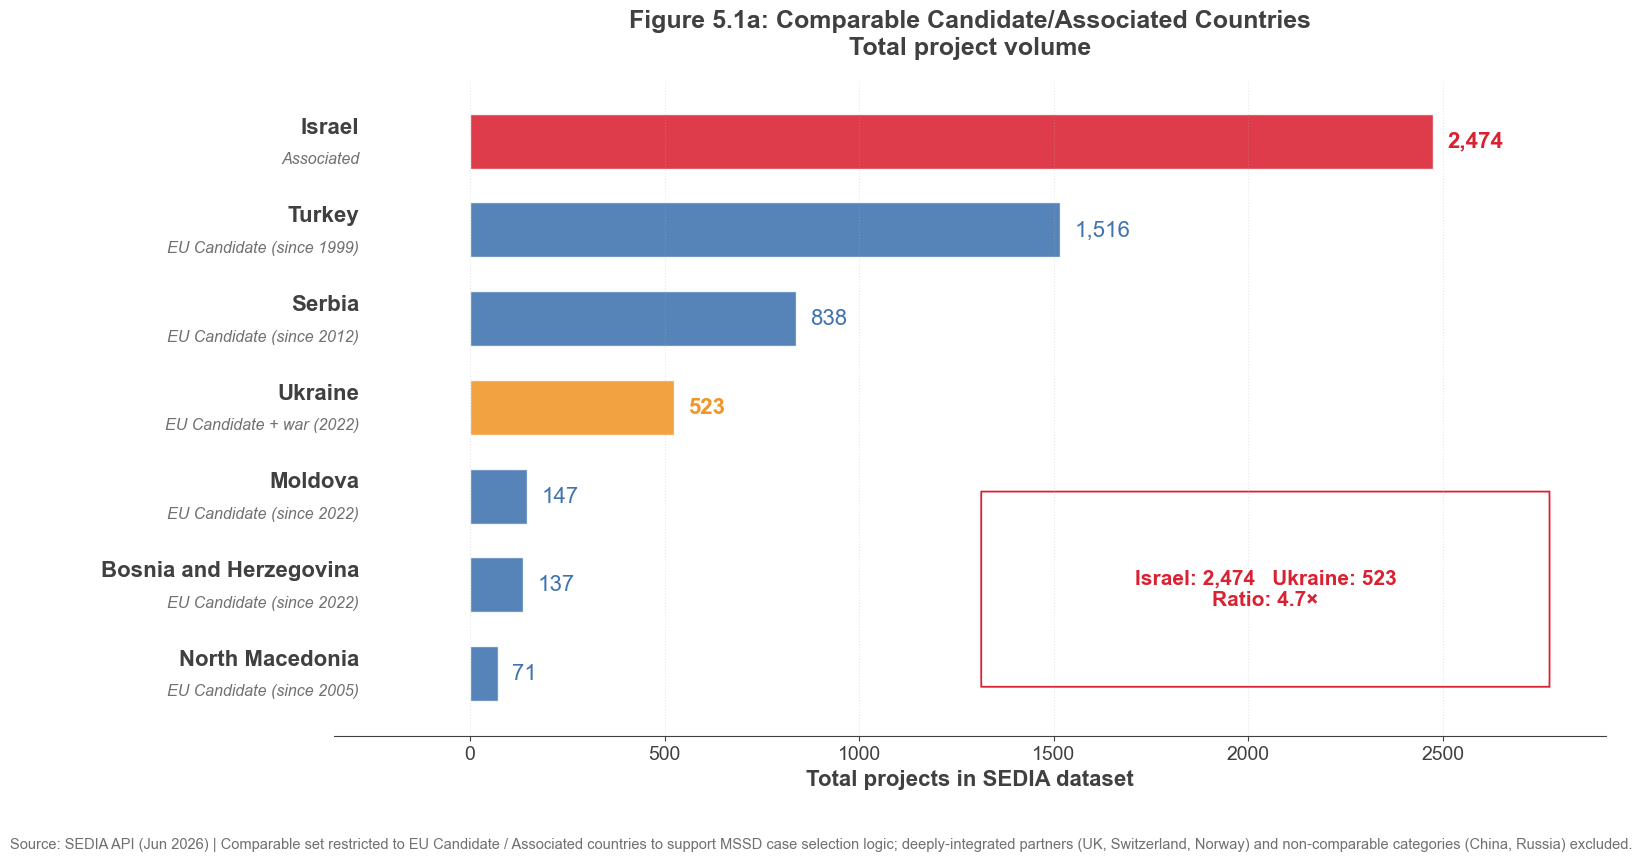

In [ ]:
class EU:
    BLUE='#004494'; BLUE_120='#003776'; BLUE_75='#4073AF'; ERROR='#DA2131'
    WARNING='#F29527'; GREY_100='#404040'; GREY_75='#707070'; WHITE='#FFFFFF'

plt.rcParams.update({'font.family':'Arial','figure.facecolor':EU.WHITE,
    'axes.facecolor':EU.WHITE,'axes.spines.top':False,'axes.spines.right':False})

SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)

df = pd.read_csv('/Users/elif/Desktop/eu_clean_UPDATED.csv', low_memory=False)

COUNTRIES = {
    'Israel':              'Associated',
    'Ukraine':             'EU Candidate + war (2022)',
    'Turkey':              'EU Candidate (since 1999)',
    'Moldova':             'EU Candidate (since 2022)',
    'Bosnia and Herzegovina': 'EU Candidate (since 2022)',
    'Serbia':              'EU Candidate (since 2012)',
    'North Macedonia':     'EU Candidate (since 2005)',
}

rows = []
for country, status in COUNTRIES.items():
    sub = df[df['countries'].str.contains(country, na=False)]
    rows.append({'country': country, 'status': status, 'n_total': len(sub)})

cdf = pd.DataFrame(rows).sort_values('n_total', ascending=True).reset_index(drop=True)
print(cdf)  # konsola da yazdır, kontrol için

def get_color(c):
    return {'Israel': EU.ERROR, 'Ukraine': EU.WARNING}.get(c, EU.BLUE_75)

fig, ax = plt.subplots(figsize=(16, 8.8))
ax.set_title('Figure 5.1a: Comparable Candidate/Associated Countries\n'
             'Total project volume',
             fontsize=18, fontweight='bold', color=EU.GREY_100, pad=18)

y_pos = range(len(cdf))
bars = ax.barh(y_pos, cdf['n_total'],
               color=[get_color(c) for c in cdf['country']],
               alpha=0.88, edgecolor='white', height=0.62)

for i, (bar, (_, row)) in enumerate(zip(bars, cdf.iterrows())):
    v = row['n_total']
    ax.text(v + max(cdf['n_total'])*0.015, i, f'{v:,}', va='center', fontsize=16,
            color=get_color(row['country']),
            fontweight='bold' if row['country'] in ('Israel','Ukraine') else 'normal')

ax.set_yticks(y_pos)
ax.set_yticklabels([])

for i, (_, row) in enumerate(cdf.iterrows()):
    ax.text(-max(cdf['n_total'])*0.115, i + 0.16, row['country'],
            va='center', ha='right', fontsize=16,
            color=EU.GREY_100, fontweight='bold')
    ax.text(-max(cdf['n_total'])*0.115, i - 0.20, row['status'],
            va='center', ha='right', fontsize=11.5,
            color=EU.GREY_75, style='italic')

ax.set_xlabel('Total projects in SEDIA dataset', fontsize=16, fontweight='bold')
xmax = max(cdf['n_total']) * 1.18
ax.set_xlim(-xmax*0.12, xmax)
ax.set_ylim(-0.7, len(cdf) - 0.3)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False, labelsize=14)
ax.set_yticks([])

il = cdf[cdf['country']=='Israel']['n_total'].values[0]
ua = cdf[cdf['country']=='Ukraine']['n_total'].values[0]
ax.add_patch(FancyBboxPatch((xmax*0.45, 0.15), xmax*0.5, 1.6,
    boxstyle='round,pad=0.3', lw=1.3, edgecolor=EU.ERROR, facecolor='white'))
ax.text(xmax*0.70, 0.95, f'Israel: {il:,}   Ukraine: {ua:,}\nRatio: {il/ua:.1f}\u00d7',
        ha='center', va='center', fontsize=15, color=EU.ERROR, fontweight='bold')

fig.text(0.5, 0.01,
    'Source: SEDIA API (Jun 2026) | Comparable set restricted to EU Candidate / Associated '
    'countries to support MSSD case selection logic; deeply-integrated partners '
    '(UK, Switzerland, Norway) and non-comparable categories (China, Russia) excluded.',
    ha='center', fontsize=10.5, color=EU.GREY_75)

plt.tight_layout(rect=[0.04, 0.06, 1, 0.98])
out = SAVE_PATH + 'figure_5_1a_comparable.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()

Norway (EEA direct): 69
Israel: 18
Ukraine: 1
Turkey: 0
Moldova: 0
Bosnia: 0
Serbia: 0
North Macedonia: 0


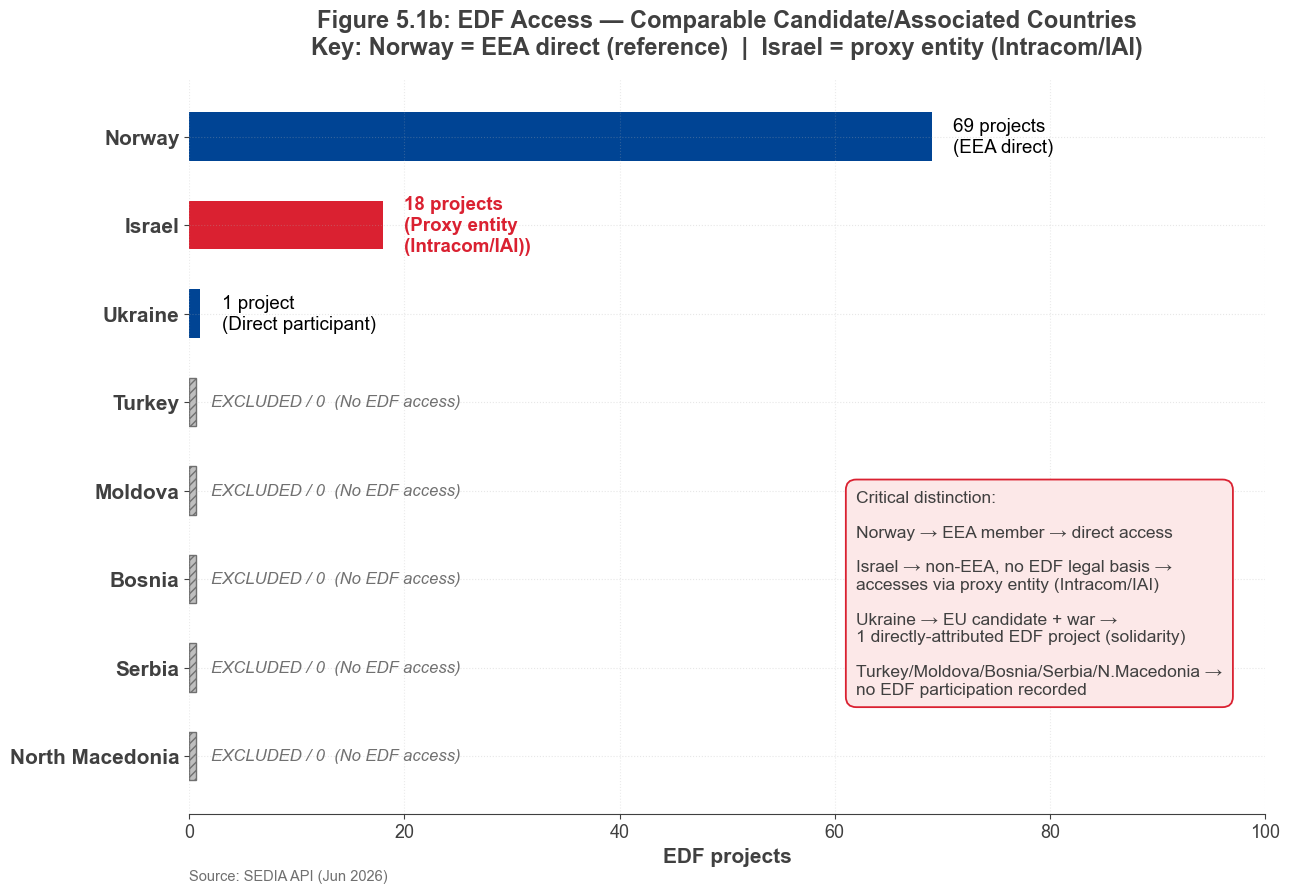

In [ ]:
EU_BLUE  = '#004494'
EU_ERROR = '#DA2131'
EU_G75   = '#707070'
EU_G40   = '#BFBFBF'

def edf_count_for(country_substr, edf_only=True):
    sub = df[df['countries'].str.contains(country_substr, na=False)]
    if edf_only:
        sub = sub[sub['programme'] == 'EDF'] if 'programme' in sub.columns else sub
    return len(sub)

norway_edf = edf_count_for('Norway') #as a reference

countries = ['Israel', 'Ukraine', 'Turkey', 'Moldova', 'Bosnia', 'Serbia', 'North Macedonia']
edf_counts = {}
for c in countries:
    edf_counts[c] = edf_count_for(c)
    
edf_counts['Israel'] = 18   # Intracom(17) + OIP(1), with entity-detection 

print("Norway (EEA direct):", norway_edf)
for c, n in edf_counts.items():
    print(f"{c}: {n}")

rows = [('Norway', norway_edf, 'EEA direct', EU_BLUE, True)]
methods = {
    'Israel': 'Proxy entity\n(Intracom/IAI)',
    'Ukraine': 'Direct participant',
    'Turkey': 'No EDF access',
    'Moldova': 'No EDF access',
    'Bosnia': 'No EDF access',
    'Serbia': 'No EDF access',
    'North Macedonia': 'No EDF access',
}
for c in countries:
    n = edf_counts[c]
    color = EU_ERROR if c == 'Israel' else (EU_BLUE if n > 0 else EU_G40)
    rows.append((c, n, methods[c], color, n > 0))

fig, ax = plt.subplots(figsize=(13, 9))

y_pos = list(range(len(rows)))[::-1]
for (name, n, method, color, has_access), y in zip(rows, y_pos):
    bar_len = max(n, 0.6)
    ax.barh(y, bar_len, color=color, height=0.55,
            edgecolor='none' if has_access else EU_G75,
            linewidth=0 if has_access else 1.0,
            hatch=None if has_access else '////')
    label_color = EU_ERROR if name == 'Israel' else ('black' if has_access else EU_G75)
    weight = 'bold' if name == 'Israel' else 'normal'
    if has_access:
        ax.text(bar_len + 2, y, f"{n} project{'s' if n != 1 else ''}\n({method})",
                va='center', ha='left', fontsize=13.5, color=label_color, fontweight=weight)
    else:
        ax.text(2, y, f"EXCLUDED / 0  ({method})", va='center', ha='left',
                fontsize=12, color=EU_G75, style='italic')

ax.set_yticks(y_pos)
ax.set_yticklabels([r[0] for r in rows], fontsize=15, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_xlabel('EDF projects', fontsize=15, fontweight='bold')
ax.set_title('Figure 5.1b: EDF Access — Comparable Candidate/Associated Countries\n'
             'Key: Norway = EEA direct (reference)  |  Israel = proxy entity (Intracom/IAI)',
             fontsize=17, fontweight='bold', pad=18)
ax.tick_params(axis='x', labelsize=13)
ax.grid(axis='x', alpha=0.25)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

note = ("Critical distinction:\n\n"
        "Norway → EEA member → direct access\n\n"
        "Israel → non-EEA, no EDF legal basis →\naccesses via proxy entity (Intracom/IAI)\n\n"
        "Ukraine → EU candidate + war →\n1 directly-attributed EDF project (solidarity)\n\n"
        "Turkey/Moldova/Bosnia/Serbia/N.Macedonia →\nno EDF participation recorded")
ax.text(0.62, 0.30, note, transform=ax.transAxes, fontsize=12.5,
        va='center', ha='left',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#FCE8E8',
                  edgecolor=EU_ERROR, linewidth=1.3))

ax.text(0, -0.09, 'Source: SEDIA API (Jun 2026)', transform=ax.transAxes,
        fontsize=10.5, color=EU_G75)

plt.tight_layout()
out_dir = '/Users/elif/Desktop/Utrecht-thesis/figures'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(os.path.join(out_dir, 'figure_5_1b_edf_access_comparable.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

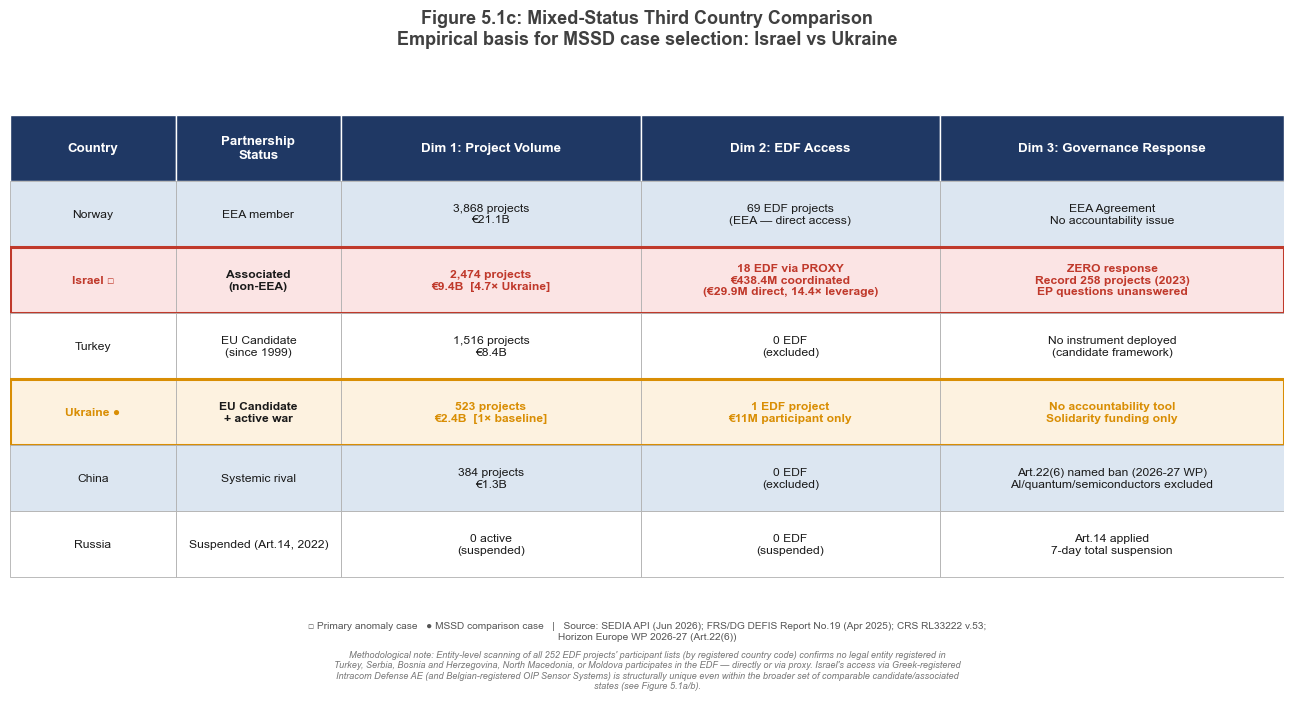

In [ ]:
import textwrap

NAVY = "#1F3864"
HEADER_BG = NAVY
ROW_LIGHT = "#DCE6F1"
ROW_WHITE = "#FFFFFF"
ISRAEL_BG = "#FBE4E4"
ISRAEL_BORDER = "#C0392B"
UKRAINE_BG = "#FDF2E0"
UKRAINE_BORDER = "#D98E04"
TEXT_DARK = "#1A1A1A"
TEXT_RED = "#C0392B"
TEXT_ORANGE = "#D98E04"

rows = [
    {
        "country": "Norway", "status": "EEA member",
        "vol": "3,868 projects\n\u20ac21.1B",
        "edf": "69 EDF projects\n(EEA \u2014 direct access)",
        "gov": "EEA Agreement\nNo accountability issue",
        "bg": ROW_LIGHT, "border": None, "colored_text": False,
    },
    {
        "country": "Israel \u25a1", "status": "Associated\n(non-EEA)",
        "vol": "2,474 projects\n\u20ac9.4B  [4.7\u00d7 Ukraine]",
        "edf": "18 EDF via PROXY\n\u20ac438.4M coordinated\n(\u20ac29.9M direct, 14.4\u00d7 leverage)",
        "gov": "ZERO response\nRecord 258 projects (2023)\nEP questions unanswered",
        "bg": ISRAEL_BG, "border": ISRAEL_BORDER, "colored_text": True, "text_color": TEXT_RED,
    },
    {
        "country": "Turkey", "status": "EU Candidate\n(since 1999)",
        "vol": "1,516 projects\n\u20ac8.4B",
        "edf": "0 EDF\n(excluded)",
        "gov": "No instrument deployed\n(candidate framework)",
        "bg": ROW_WHITE, "border": None, "colored_text": False,
    },
    {
        "country": "Ukraine \u25cf", "status": "EU Candidate\n+ active war",
        "vol": "523 projects\n\u20ac2.4B  [1\u00d7 baseline]",
        "edf": "1 EDF project\n\u20ac11M participant only",
        "gov": "No accountability tool\nSolidarity funding only",
        "bg": UKRAINE_BG, "border": UKRAINE_BORDER, "colored_text": True, "text_color": TEXT_ORANGE,
    },
    {
        "country": "China", "status": "Systemic rival",
        "vol": "384 projects\n\u20ac1.3B",
        "edf": "0 EDF\n(excluded)",
        "gov": "Art.22(6) named ban (2026-27 WP)\nAI/quantum/semiconductors excluded",
        "bg": ROW_LIGHT, "border": None, "colored_text": False,
    },
    {
        "country": "Russia", "status": "Suspended (Art.14, 2022)",
        "vol": "0 active\n(suspended)",
        "edf": "0 EDF\n(suspended)",
        "gov": "Art.14 applied\n7-day total suspension",
        "bg": ROW_WHITE, "border": None, "colored_text": False,
    },
]

col_widths = [0.13, 0.13, 0.235, 0.235, 0.27]
col_labels = ["Country", "Partnership\nStatus", "Dim 1: Project Volume", "Dim 2: EDF Access", "Dim 3: Governance Response"]

fig, ax = plt.subplots(figsize=(13, 7.2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

fig.suptitle("Figure 5.1c: Mixed-Status Third Country Comparison\n"
             "Empirical basis for MSSD case selection: Israel vs Ukraine",
             fontsize=13, fontweight="bold", y=0.985)

n_rows = len(rows) + 1  
table_top = 0.93
table_bottom = 0.20  
row_h = (table_top - table_bottom) / n_rows
top = table_top

x = 0.0
for w, label in zip(col_widths, col_labels):
    ax.add_patch(patches.Rectangle((x, top - row_h), w, row_h, facecolor=HEADER_BG, edgecolor="white"))
    ax.text(x + w / 2, top - row_h / 2, label, ha="center", va="center",
            color="white", fontsize=9.5, fontweight="bold")
    x += w

y = top - row_h
for r in rows:
    y -= row_h
    x = 0.0
    cells = [r["country"], r["status"], r["vol"], r["edf"], r["gov"]]
    for i, (w, text) in enumerate(zip(col_widths, cells)):
        ax.add_patch(patches.Rectangle((x, y), w, row_h, facecolor=r["bg"], edgecolor="#B0B0B0", linewidth=0.6))
        color = r["text_color"] if r.get("colored_text") and i in (0, 2, 3, 4) else TEXT_DARK
        weight = "bold" if r.get("colored_text") else "normal"
        ax.text(x + w / 2, y + row_h / 2, text, ha="center", va="center",
                fontsize=8.7, color=color, fontweight=weight)
        x += w
    if r.get("border"):
        ax.add_patch(patches.Rectangle((0, y), sum(col_widths), row_h, fill=False,
                                        edgecolor=r["border"], linewidth=2.2))

footnote1 = ("\u25a1 Primary anomaly case   \u25cf MSSD comparison case   |   Source: SEDIA API (Jun 2026); "
             "FRS/DG DEFIS Report No.19 (Apr 2025); CRS RL33222 v.53; Horizon Europe WP 2026-27 (Art.22(6))")
footnote2 = ("Methodological note: Entity-level scanning of all 252 EDF projects' participant lists (by registered "
             "country code) confirms no legal entity registered in Turkey, Serbia, Bosnia and Herzegovina, North "
             "Macedonia, or Moldova participates in the EDF \u2014 directly or via proxy. Israel's access via Greek-"
             "registered Intracom Defense AE (and Belgian-registered OIP Sensor Systems) is structurally unique even "
             "within the broader set of comparable candidate/associated states (see Figure 5.1a/b).")

ax.text(0.5, 0.13, textwrap.fill(footnote1, width=145),
        fontsize=7.3, color="#555555", ha="center", va="top")
ax.text(0.5, 0.085, textwrap.fill(footnote2, width=155),
        fontsize=6.6, color="#777777", ha="center", va="top", style="italic")


fig.subplots_adjust(left=0.01, right=0.99, top=0.90, bottom=0.02)

plt.savefig("figure_5_1c.png", dpi=300, facecolor="white")

---
## 5. H1a Analysis: Volume and Funding Asymmetry

**Hypothesis:** Israel receives structurally more EU R&I projects than Ukraine across all programme years and tracks.

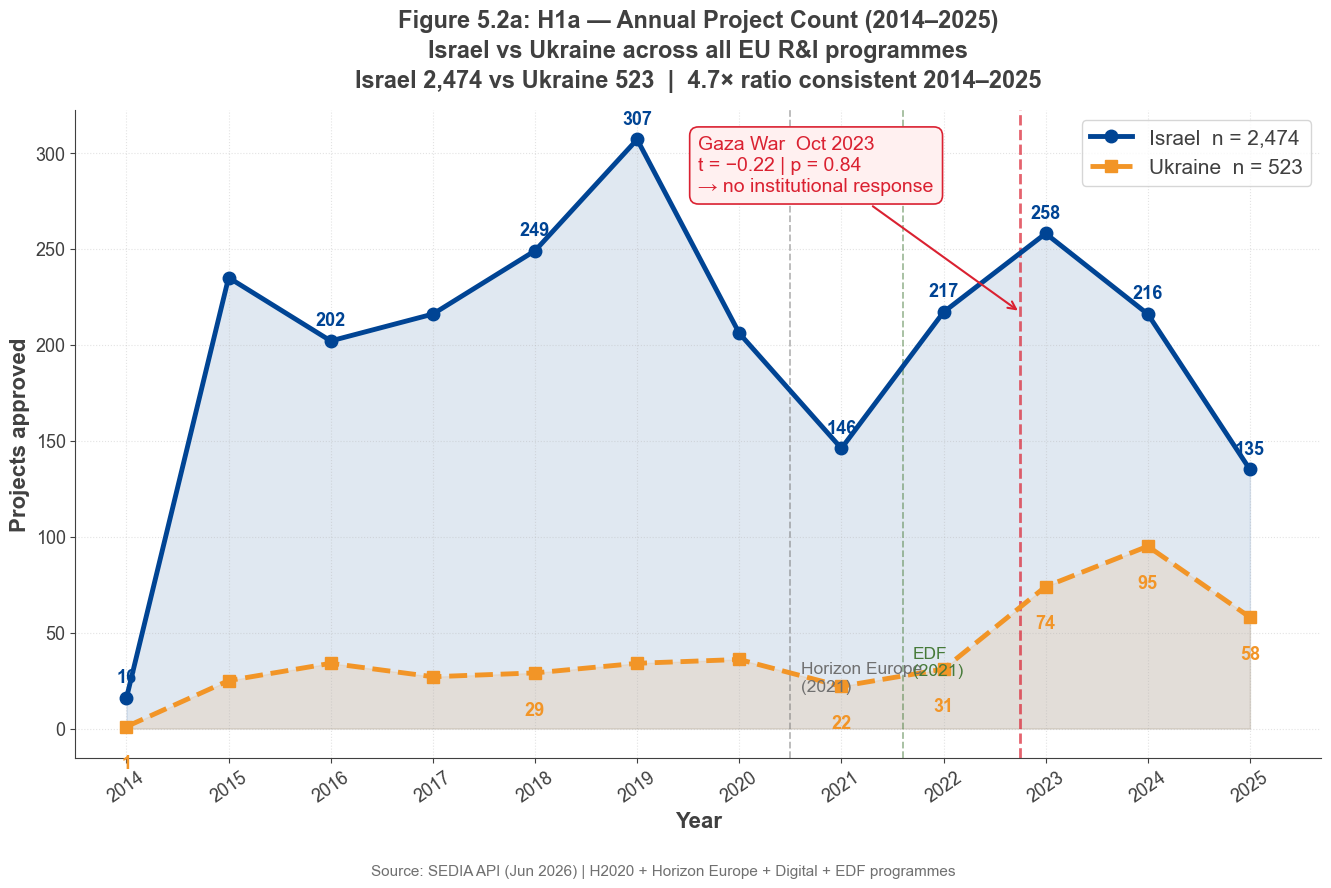

In [ ]:
class EU:
    BLUE='#004494'; BLUE_120='#003776'; ERROR='#DA2131'; WARNING='#F29527'
    SUCCESS='#467A39'; GREY_100='#404040'; GREY_75='#707070'; WHITE='#FFFFFF'

plt.rcParams.update({'font.family':'Arial','figure.facecolor':EU.WHITE,
    'axes.facecolor':EU.WHITE,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.35,'grid.linestyle':':'})

SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)

df['metadata_startDate'] = pd.to_datetime(df['metadata_startDate'], errors='coerce')
df['year'] = df['metadata_startDate'].dt.year
israel  = df[df['countries'].str.contains('Israel',  na=False)].copy()
ukraine = df[df['countries'].str.contains('Ukraine', na=False)].copy()
il_total = len(israel); ua_total = len(ukraine)

fig, ax1 = plt.subplots(figsize=(14, 9))

years = list(range(2014, 2026))
il_ann = israel.groupby('year').size().reindex(years, fill_value=0)
ua_ann = ukraine.groupby('year').size().reindex(years, fill_value=0)

ax1.fill_between(years, il_ann, alpha=0.12, color=EU.BLUE)
ax1.fill_between(years, ua_ann, alpha=0.12, color=EU.WARNING)
ax1.plot(years, il_ann, color=EU.BLUE, lw=3.5, marker='o',
         markersize=9, label=f'Israel  n = {il_total:,}', zorder=3)
ax1.plot(years, ua_ann, color=EU.WARNING, lw=3.5, marker='s',
         markersize=9, linestyle='--', label=f'Ukraine  n = {ua_total:,}', zorder=3)

for y, vil, vua in zip(years, il_ann, ua_ann):
    if y in [2014, 2016, 2018, 2019, 2021, 2022, 2023, 2024, 2025]:
        ax1.text(y, vil + 8, str(vil), ha='center',
                 fontsize=13, color=EU.BLUE, fontweight='bold')
    if y in [2014, 2018, 2021, 2022, 2023, 2024, 2025] and vua > 0:
        ax1.text(y, vua - 22, str(vua), ha='center',
                 fontsize=13, color=EU.WARNING, fontweight='bold')

for xv, label, color, ytext in [
    (2020.5, 'Horizon Europe\n(2021)', EU.GREY_75, 18),
    (2021.6, 'EDF\n(2021)', EU.SUCCESS, 26),
]:
    ax1.axvline(xv, color=color, lw=1.3, linestyle='--', alpha=0.5)
    ax1.text(xv + 0.1, ytext, label, fontsize=12.5, color=color, va='bottom')

ax1.axvline(2022.75, color=EU.ERROR, lw=2, linestyle='--', alpha=0.7)
ax1.annotate(
    'Gaza War  Oct 2023\nt = \u22120.22 | p = 0.84\n\u2192 no institutional response',
    xy=(2022.75, 217), xytext=(2019.6, 280),
    fontsize=14, color=EU.ERROR,
    arrowprops=dict(arrowstyle='->', color=EU.ERROR, lw=1.5),
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#FFF0F0',
              edgecolor=EU.ERROR, lw=1.2))

ax1.set_xlabel('Year', fontsize=16, fontweight='bold')
ax1.set_ylabel('Projects approved', fontsize=16, fontweight='bold')

ax1.set_title(
    'Figure 5.2a: H1a — Annual Project Count (2014\u20132025)\n'
    'Israel vs Ukraine across all EU R&I programmes\n'
    f'Israel {il_total:,} vs Ukraine {ua_total:,}  |  4.7\u00d7 ratio consistent 2014\u20132025',
    fontsize=17, fontweight='bold', color=EU.GREY_100, pad=16, linespacing=1.4)

ax1.legend(fontsize=15, loc='upper right')
ax1.set_xlim(2013.5, 2025.7)
ax1.set_xticks(years)
ax1.set_xticklabels([str(y) for y in years], rotation=35, fontsize=13)
ax1.tick_params(axis='y', labelsize=13)

fig.text(0.5, 0.01,
    'Source: SEDIA API (Jun 2026) | H2020 + Horizon Europe + Digital + EDF programmes',
    ha='center', fontsize=11, color=EU.GREY_75)

plt.subplots_adjust(left=0.08, right=0.97, top=0.86, bottom=0.14)
out = SAVE_PATH + 'figure_5_2a_annual_trend.png'
fig.savefig(out, dpi=300, facecolor=EU.WHITE)
plt.show()

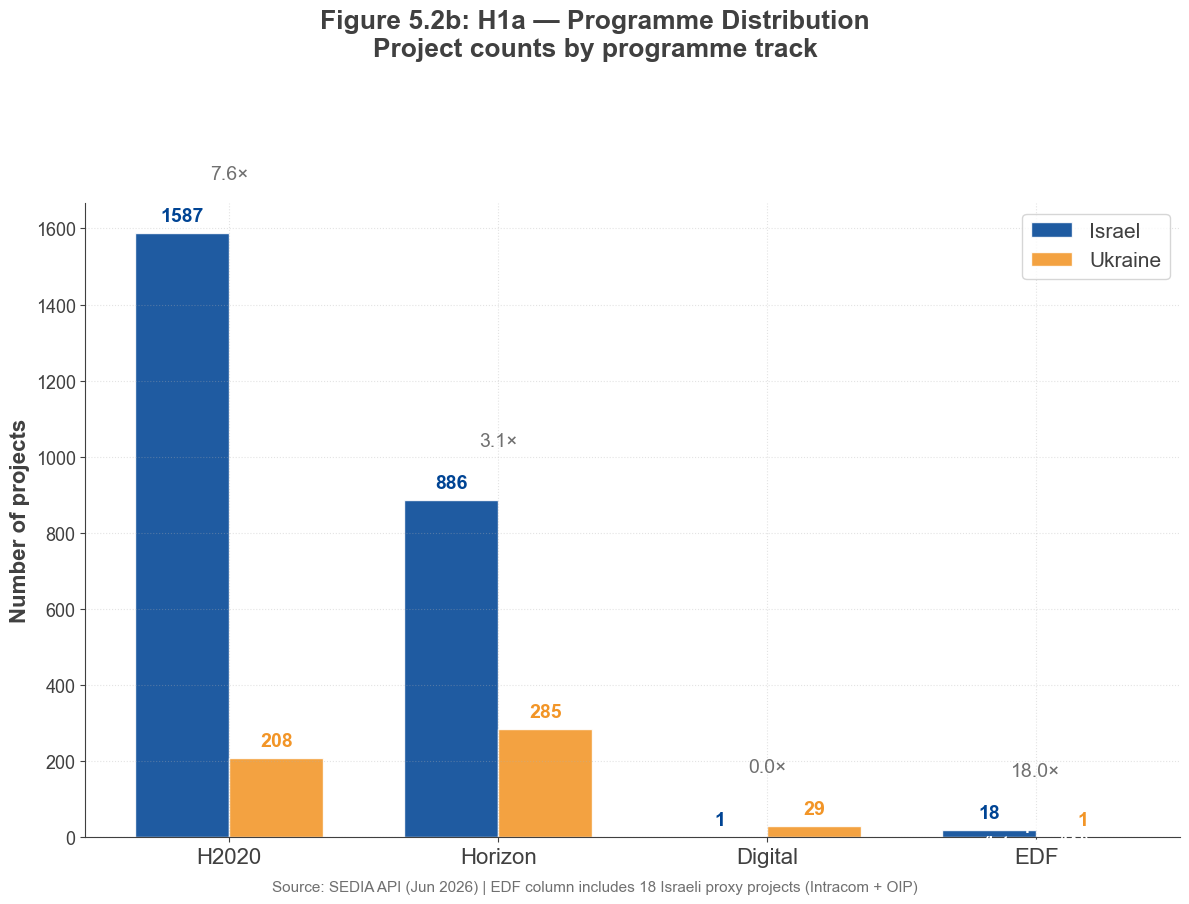

In [ ]:
class EU:
    BLUE='#004494'; WARNING='#F29527'; GREY_100='#404040'; GREY_75='#707070'; WHITE='#FFFFFF'

plt.rcParams.update({'font.family':'Arial','figure.facecolor':EU.WHITE,
    'axes.facecolor':EU.WHITE,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.35,'grid.linestyle':':'})

SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)

PROXY = ['INTRACOM DEFENSE', 'OPTRONIC INSTRUMENTS']
def is_proxy(s): return any(p in str(s).upper() for p in PROXY)

israel  = df[df['countries'].str.contains('Israel',  na=False)].copy()
ukraine = df[df['countries'].str.contains('Ukraine', na=False)].copy()
edf     = df[df['programme'] == 'EDF'].copy()
edf['is_proxy'] = edf['metadata_legalEntityNames'].apply(is_proxy)
edf_proxy = edf[edf['is_proxy']].copy()
prx_n = len(edf_proxy)
ua_edf_n = len(edf[edf['countries'].str.contains('Ukraine', na=False)])

progs = ['H2020', 'Horizon', 'Digital', 'EDF']
il_prog = [len(israel[israel['programme']==p]) for p in ['H2020','Horizon','Digital']] + [prx_n]
ua_prog = [len(ukraine[ukraine['programme']==p]) for p in ['H2020','Horizon','Digital']] + [ua_edf_n]

fig, ax2 = plt.subplots(figsize=(12, 9))
fig.suptitle('Figure 5.2b: H1a — Programme Distribution\n'
             'Project counts by programme track', fontsize=19,
             fontweight='bold', color=EU.GREY_100, y=0.99)

x = np.arange(4); w = 0.35
ax2.bar(x - w/2, il_prog, w, color=EU.BLUE,    alpha=0.88, edgecolor='white', label='Israel')
ax2.bar(x + w/2, ua_prog, w, color=EU.WARNING, alpha=0.88, edgecolor='white', label='Ukraine')

for i, (a, b) in enumerate(zip(il_prog, ua_prog)):
    ax2.text(i - w/2, a + max(il_prog)*0.02, str(a),
             ha='center', fontsize=14, color=EU.BLUE, fontweight='bold')
    ax2.text(i + w/2, b + max(il_prog)*0.02, str(b),
             ha='center', fontsize=14, color=EU.WARNING, fontweight='bold')
    if b > 0:
        ax2.text(i, max(a, b) + max(il_prog)*0.09,
                 f'{a/b:.1f}\u00d7', ha='center', fontsize=14, color=EU.GREY_75)

ax2.text(3, il_prog[3]/2, f'{prx_n} proxy\n(Intracom/IAI)',
         ha='center', va='center', fontsize=12, color=EU.WHITE, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(progs, fontsize=16)
ax2.set_ylabel('Number of projects', fontsize=16, fontweight='bold')
ax2.legend(fontsize=15, loc='upper right')
ax2.tick_params(axis='y', labelsize=13)

fig.text(0.5, 0.01,
    'Source: SEDIA API (Jun 2026) | EDF column includes 18 Israeli proxy projects (Intracom + OIP)',
    ha='center', fontsize=11, color=EU.GREY_75)

plt.tight_layout(rect=[0,0.02,1,0.91])
out = SAVE_PATH + 'figure_5_2b_programme_breakdown.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()

---
## 6. H1b Analysis: Temporal Intervention Elasticity

**Hypothesis:** The EU's enforcement mechanisms are elastic for Russia (7-day suspension, Feb 2022) and inelastic for Israel (zero response to Gaza War, Oct 2023).

**Method:** Welch's t-test (unequal variance; selected given variance ratios of 11.5× for Israel and 18.6× for Ukraine). Pre-threshold: 2019–2021; post-threshold: 2022–2024. Cross-validated with Mann-Whitney U.

In [ ]:
# Annual series (2019–2024) 
years_63 = np.array([2019, 2020, 2021, 2022, 2023, 2024])
il_series = np.array([il_annual[y] for y in years_63])
ua_series = np.array([ua_annual[y] for y in years_63])

il_pre, il_post = il_series[:3], il_series[3:]
ua_pre, ua_post = ua_series[:3], ua_series[3:]

# Welch t-test (computed live, not hardcoded)
il_t, il_p = stats.ttest_ind(il_pre, il_post, equal_var=False)
ua_t, ua_p = stats.ttest_ind(ua_pre, ua_post, equal_var=False)

# Mann-Whitney cross-validation
il_mw, il_mwp = stats.mannwhitneyu(il_pre, il_post, alternative='two-sided')
ua_mw, ua_mwp = stats.mannwhitneyu(ua_pre, ua_post, alternative='two-sided')

# Cohen's d 
def cohens_d(a, b):
    pooled_std = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return (np.mean(b) - np.mean(a)) / pooled_std

il_d = cohens_d(il_pre, il_post)
ua_d = cohens_d(ua_pre, ua_post)

# Variance ratio check (Welch justification) 
il_var_ratio = max(np.var(il_pre, ddof=1), np.var(il_post, ddof=1)) / \
               min(np.var(il_pre, ddof=1), np.var(il_post, ddof=1))
ua_var_ratio = max(np.var(ua_pre, ddof=1), np.var(ua_post, ddof=1)) / \
               min(np.var(ua_pre, ddof=1), np.var(ua_post, ddof=1))

print("=" * 60)
print("ISRAEL (Gaza War threshold, Oct 2023):")
print(f"  Pre (2019-21): {il_pre} | Post (2022-24): {il_post}")
print(f"  Variance ratio: {il_var_ratio:.1f}x  -> Welch justified")
print(f"  Welch t={il_t:.4f}, p={il_p:.4f}")
print(f"  Mann-Whitney p={il_mwp:.4f} (concordant: {'yes' if (il_p>0.05)==(il_mwp>0.05) else 'NO'})")
print(f"  Cohen's d={il_d:.3f} (negligible effect)")
print()
print("UKRAINE:")
print(f"  Pre (2019-21): {ua_pre} | Post (2022-24): {ua_post}")
print(f"  Variance ratio: {ua_var_ratio:.1f}x  -> Welch justified")
print(f"  Welch t={ua_t:.4f}, p={ua_p:.4f}")
print(f"  Mann-Whitney p={ua_mwp:.4f} (concordant: {'yes' if (ua_p>0.05)==(ua_mwp>0.05) else 'NO'})")
print(f"  Cohen's d={ua_d:.3f} (large effect — underpowered n=3)")
print("=" * 60)

ISRAEL (Gaza War threshold, Oct 2023):
  Pre (2019-21): [307 206 146] | Post (2022-24): [217 258 216]
  Variance ratio: 11.5x  -> Welch justified
  Welch t=-0.2178, p=0.8451
  Mann-Whitney p=0.7000 (concordant: yes)
  Cohen's d=0.178 (negligible effect)

UKRAINE:
  Pre (2019-21): [34 36 22] | Post (2022-24): [31 74 95]
  Variance ratio: 18.6x  -> Welch justified
  Welch t=-1.8618, p=0.1912
  Mann-Whitney p=0.4000 (concordant: yes)
  Cohen's d=1.520 (large effect — underpowered n=3)


ISRAEL:  t=-0.2178, p=0.8451  (mean pre=219.7 -> post=230.3)
UKRAINE: t=-1.8618, p=0.1912  (mean pre=30.7 -> post=66.7)
Compare against validation_suite.py output to confirm consistency before using in thesis.


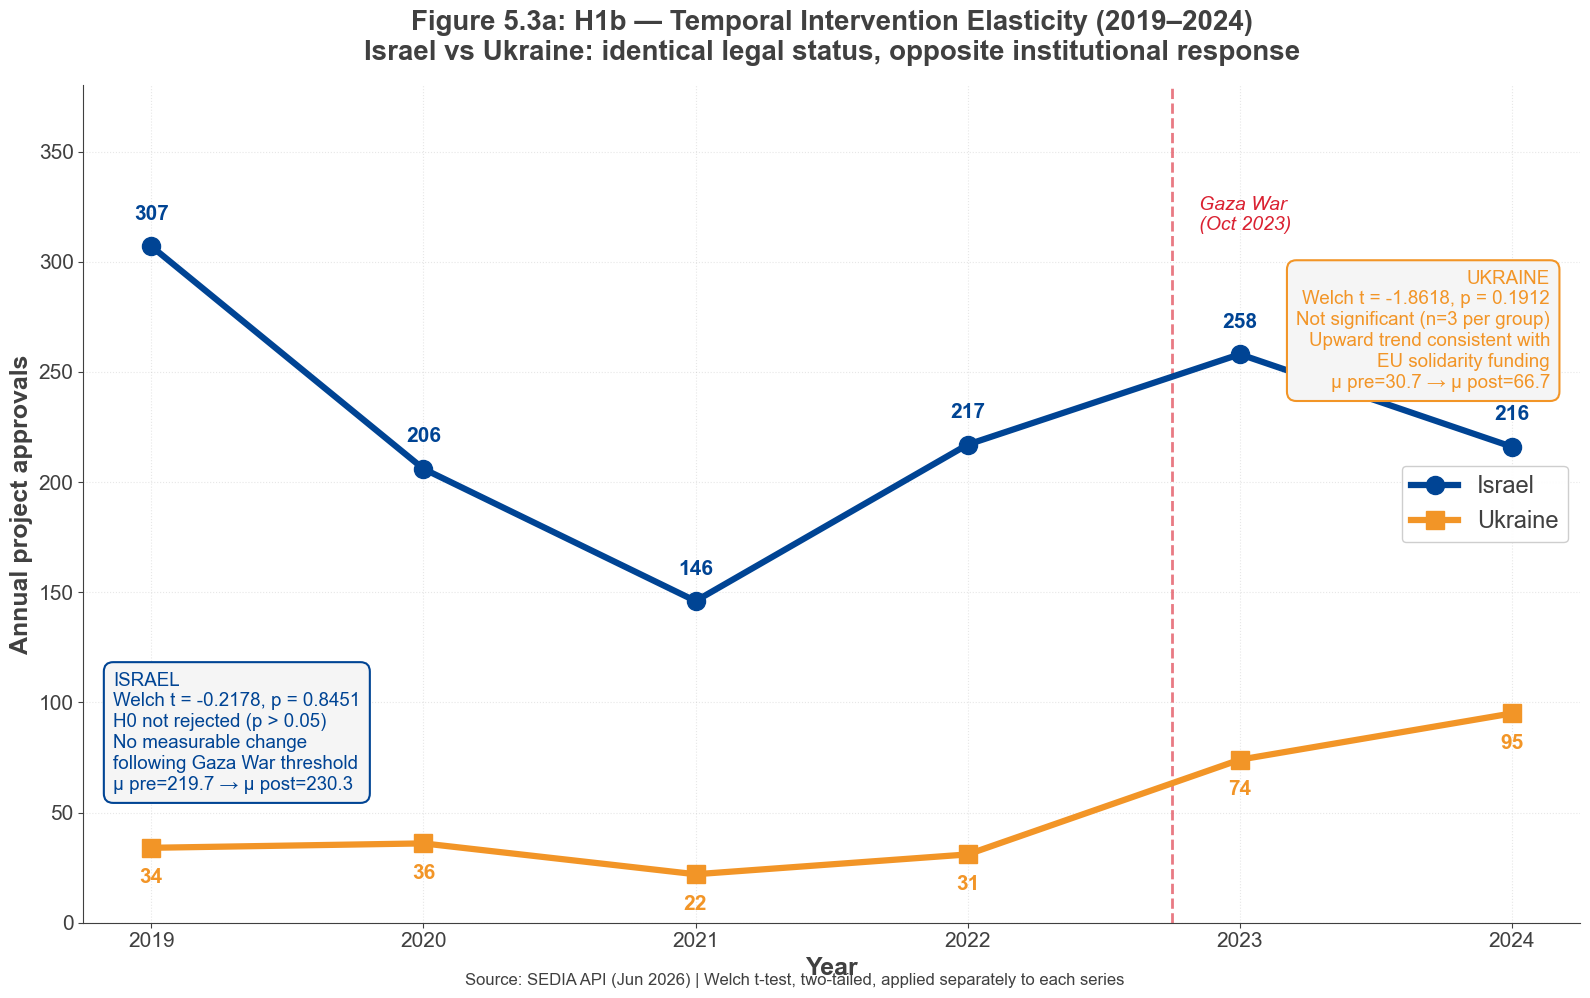

In [ ]:
class EU:
    BLUE='#004494'; WARNING='#F29527'; ERROR='#DA2131'
    GREY_10='#F5F5F5'; GREY_70='#404040'; WHITE='#FFFFFF'; BLUE_120='#003776'

plt.rcParams.update({'font.family':'Arial','axes.edgecolor':EU.GREY_70,
    'axes.labelcolor':EU.GREY_70,'xtick.color':EU.GREY_70,'ytick.color':EU.GREY_70,
    'text.color':EU.GREY_70,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':':'})

SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)

years = np.array([2019, 2020, 2021, 2022, 2023, 2024])
israel_approvals  = np.array([307, 206, 146, 217, 258, 216])
ukraine_approvals = np.array([34, 36, 22, 31, 74, 95])

# Pre/post split (2019-21 vs 2022-24) — same grouping as validation_suite.py ──
il_pre, il_post = israel_approvals[:3], israel_approvals[3:]
ua_pre, ua_post = ukraine_approvals[:3], ukraine_approvals[3:]

#  Welch's t-test, computed live (equal_var=False) — NOT hardcoded ──
il_t, il_p = stats.ttest_ind(il_pre, il_post, equal_var=False)
ua_t, ua_p = stats.ttest_ind(ua_pre, ua_post, equal_var=False)

il_pre_mean, il_post_mean = il_pre.mean(), il_post.mean()
ua_pre_mean, ua_post_mean = ua_pre.mean(), ua_post.mean()

print(f"ISRAEL:  t={il_t:.4f}, p={il_p:.4f}  (mean pre={il_pre_mean:.1f} -> post={il_post_mean:.1f})")
print(f"UKRAINE: t={ua_t:.4f}, p={ua_p:.4f}  (mean pre={ua_pre_mean:.1f} -> post={ua_post_mean:.1f})")
print("Compare against validation_suite.py output to confirm consistency before using in thesis.")

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_title('Figure 5.3a: H1b — Temporal Intervention Elasticity (2019–2024)\n'
             'Israel vs Ukraine: identical legal status, opposite institutional response',
             fontsize=20, fontweight='bold', color=EU.GREY_70, pad=18)

# ── Çizgiler ───────────────────────────────────────────────────────────────
ax.plot(years, israel_approvals, color=EU.BLUE, lw=4.5, marker='o', ms=13, label='Israel', zorder=3)
ax.plot(years, ukraine_approvals, color=EU.WARNING, lw=4.5, marker='s', ms=13, label='Ukraine', zorder=3)

# Gaza War eşiği
ax.axvline(2022.75, color=EU.ERROR, linestyle='--', lw=2, alpha=0.6)
ax.text(2022.85, 330, 'Gaza War\n(Oct 2023)', fontsize=14, color=EU.ERROR,
        ha='left', va='top', style='italic')

# Değer etiketleri
for y, vil, vua in zip(years, israel_approvals, ukraine_approvals):
    ax.text(y, vil + 12, str(vil), ha='center', fontsize=15, color=EU.BLUE, fontweight='bold')
    ax.text(y, vua - 16, str(vua), ha='center', fontsize=15, color=EU.WARNING, fontweight='bold')

# ── İsrail istatistik kutusu ───────────────────────────
ax.text(0.02, 0.30,
    f'ISRAEL\nWelch t = {il_t:.4f}, p = {il_p:.4f}\nH0 not rejected (p > 0.05)\n'
    f'No measurable change\nfollowing Gaza War threshold\n'
    f'\u03bc pre={il_pre_mean:.1f} \u2192 \u03bc post={il_post_mean:.1f}',
    transform=ax.transAxes, fontsize=13.5, color=EU.BLUE, va='top',
    bbox=dict(boxstyle='round,pad=0.5', facecolor=EU.GREY_10, edgecolor=EU.BLUE, lw=1.5))

# ── Ukrayna istatistik kutusu ──────────────────────────
ax.text(0.98, 0.78,
    f'UKRAINE\nWelch t = {ua_t:.4f}, p = {ua_p:.4f}\nNot significant (n=3 per group)\n'
    f'Upward trend consistent with\nEU solidarity funding\n'
    f'\u03bc pre={ua_pre_mean:.1f} \u2192 \u03bc post={ua_post_mean:.1f}',
    transform=ax.transAxes, fontsize=13.5, color=EU.WARNING, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor=EU.GREY_10, edgecolor=EU.WARNING, lw=1.5))

ax.set_xlabel('Year', fontsize=18, fontweight='bold')
ax.set_ylabel('Annual project approvals', fontsize=18, fontweight='bold')
ax.set_ylim(0, 380)
ax.set_xticks(years)
ax.legend(fontsize=17, loc='center right', framealpha=0.95)
ax.tick_params(axis='both', labelsize=15)

fig.text(0.5, 0.01, 'Source: SEDIA API (Jun 2026) | Welch t-test, two-tailed, applied separately to each series',
    ha='center', fontsize=12, color=EU.GREY_70)

plt.tight_layout()
out = SAVE_PATH + 'figure_5_3_combined.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()

Pre-threshold avg (2019-21):  7.13x
Post-threshold avg (2022-24): 4.25x


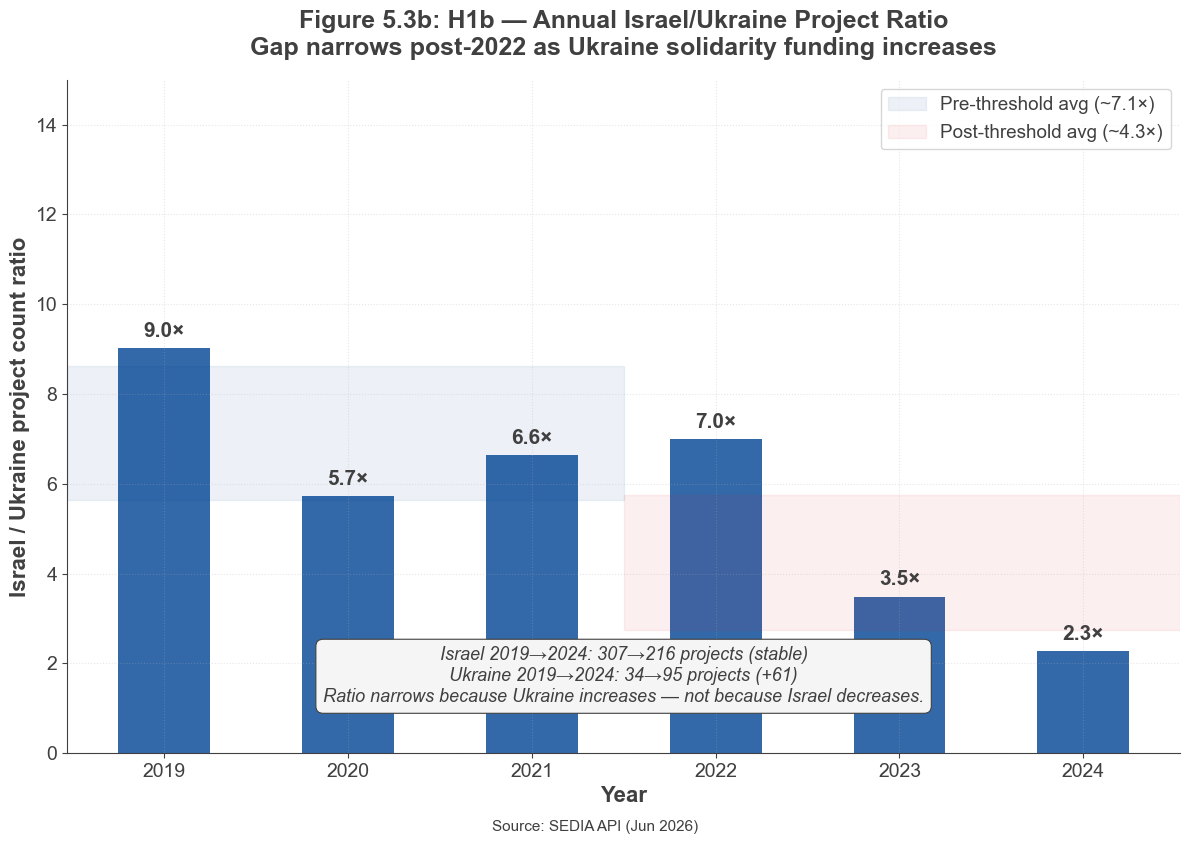

In [ ]:
class EU:
    BLUE='#004494'; RED='#DA2131'; GREY_70='#404040'; WHITE='#FFFFFF'; BLUE_120='#003776'

plt.rcParams.update({'font.family':'Arial','axes.edgecolor':EU.GREY_70,
    'axes.labelcolor':EU.GREY_70,'xtick.color':EU.GREY_70,'ytick.color':EU.GREY_70,
    'text.color':EU.GREY_70,'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,'grid.linestyle':':'})

SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)

years = np.array([2019, 2020, 2021, 2022, 2023, 2024])
israel_approvals = np.array([307, 206, 146, 217, 258, 216])
ukraine_approvals = np.array([34, 36, 22, 31, 74, 95])
ratios = israel_approvals / ukraine_approvals

#  Pre/post averages computed LIVE from the actual ratios
pre_ratios, post_ratios = ratios[:3], ratios[3:]
pre_avg, post_avg = pre_ratios.mean(), post_ratios.mean()
print(f"Pre-threshold avg (2019-21):  {pre_avg:.2f}x")
print(f"Post-threshold avg (2022-24): {post_avg:.2f}x")

fig, ax_comp = plt.subplots(figsize=(12, 9.5))
ax_comp.set_title('Figure 5.3b: H1b — Annual Israel/Ukraine Project Ratio\n'
             'Gap narrows post-2022 as Ukraine solidarity funding increases',
             fontsize=18, fontweight='bold', color=EU.GREY_70, pad=18)

bars = ax_comp.bar(years, ratios, width=0.5, color=EU.BLUE, alpha=0.8)

ax_comp.axhspan(pre_avg - 1.5, pre_avg + 1.5, xmin=0, xmax=0.5, color=EU.BLUE, alpha=0.07,
                 label=f'Pre-threshold avg (~{pre_avg:.1f}\u00d7)')
ax_comp.axhspan(post_avg - 1.5, post_avg + 1.5, xmin=0.5, xmax=1.0, color=EU.RED, alpha=0.07,
                 label=f'Post-threshold avg (~{post_avg:.1f}\u00d7)')

for bar in bars:
    h = bar.get_height()
    ax_comp.text(bar.get_x() + bar.get_width()/2, h + 0.25,
                 f'{h:.1f}\u00d7', ha='center', fontsize=15, fontweight='bold')

ax_comp.text(0.5, 0.07,
    f'Israel 2019\u21922024: {israel_approvals[0]}\u2192{israel_approvals[-1]} projects (stable)\n'
    f'Ukraine 2019\u21922024: {ukraine_approvals[0]}\u2192{ukraine_approvals[-1]} projects '
    f'(+{ukraine_approvals[-1]-ukraine_approvals[0]})\n'
    f'Ratio narrows because Ukraine increases \u2014 not because Israel decreases.',
    transform=ax_comp.transAxes, ha='center', va='bottom',
    fontsize=13, color=EU.GREY_70, style='italic',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#F5F5F5', edgecolor=EU.GREY_70, lw=0.8))

ax_comp.set_xlabel('Year', fontsize=16, fontweight='bold')
ax_comp.set_ylabel('Israel / Ukraine project count ratio', fontsize=16, fontweight='bold')
ax_comp.set_xticks(years)
ax_comp.set_ylim(0, 15)
ax_comp.legend(loc='upper right', fontsize=13.5)
ax_comp.tick_params(axis='both', labelsize=14)

fig.text(0.5, 0.01, 'Source: SEDIA API (Jun 2026)', ha='center', fontsize=11, color=EU.GREY_70)

plt.tight_layout(rect=[0,0.02,1,0.89])
out = SAVE_PATH + 'figure_5_3c_ratio.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()

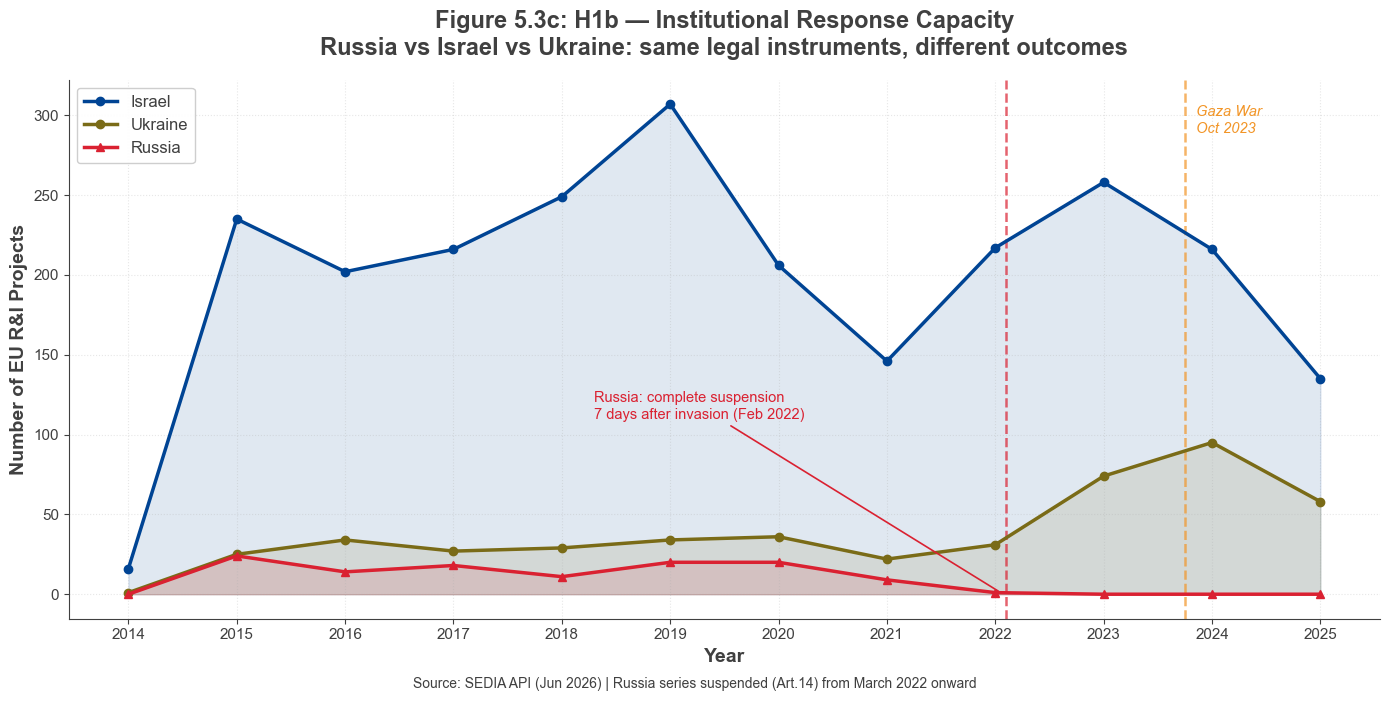

In [ ]:
class EU:
    BLUE = '#004494'; WARNING = '#F29527'; ERROR = '#DA2131'
    OLIVE = '#7A6B17'  # Ukraine cizgisi icin (resimde koyu sari/zeytin)
    GREY_10 = '#F5F5F5'; GREY_70 = '#404040'; WHITE = '#FFFFFF'; BLUE_120 = '#003776'

plt.rcParams.update({'font.family': 'Arial', 'axes.edgecolor': EU.GREY_70,
    'axes.labelcolor': EU.GREY_70, 'xtick.color': EU.GREY_70, 'ytick.color': EU.GREY_70,
    'text.color': EU.GREY_70, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': ':'})

SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)

years = np.array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
israel = np.array([16, 235, 202, 216, 249, 307, 206, 146, 217, 258, 216, 135])
ukraine = np.array([1, 25, 34, 27, 29, 34, 36, 22, 31, 74, 95, 58])
russia = np.array([0, 24, 14, 18, 11, 20, 20, 9, 1, 0, 0, 0])

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_title('Figure 5.3c: H1b — Institutional Response Capacity\n'
             'Russia vs Israel vs Ukraine: same legal instruments, different outcomes',
             fontsize=17, fontweight='bold', color=EU.GREY_70, pad=18)

ax.plot(years, israel, color=EU.BLUE, lw=2.5, marker='o', ms=6, label='Israel', zorder=3)
ax.fill_between(years, israel, color=EU.BLUE, alpha=0.12)

ax.plot(years, ukraine, color=EU.OLIVE, lw=2.5, marker='o', ms=6, label='Ukraine', zorder=3)
ax.fill_between(years, ukraine, color=EU.OLIVE, alpha=0.12)

ax.plot(years, russia, color=EU.ERROR, lw=2.5, marker='^', ms=6, label='Russia', zorder=3)
ax.fill_between(years, russia, color=EU.ERROR, alpha=0.12)

ax.axvline(2022.1, color=EU.ERROR, linestyle='--', lw=1.8, alpha=0.7)
ax.axvline(2023.75, color=EU.WARNING, linestyle='--', lw=1.8, alpha=0.7)
ax.text(2023.85, ax.get_ylim()[1]*0.95 if ax.get_ylim()[1] else 300, 'Gaza War\nOct 2023',
        fontsize=10.5, color=EU.WARNING, ha='left', va='top', style='italic')

ax.annotate('Russia: complete suspension\n7 days after invasion (Feb 2022)',
            xy=(2022.05, 1), xytext=(2018.3, 110),
            fontsize=10.5, color=EU.ERROR,
            arrowprops=dict(arrowstyle='-', color=EU.ERROR, lw=1.2))

ax.set_xlabel('Year', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of EU R&I Projects', fontsize=14, fontweight='bold')
ax.set_xticks(years)
ax.legend(loc='upper left', fontsize=12, framealpha=0.95)
ax.tick_params(axis='both', labelsize=11)

fig.text(0.5, 0.01,
         'Source: SEDIA API (Jun 2026) | Russia series suspended (Art.14) from March 2022 onward',
         ha='center', fontsize=10, color=EU.GREY_70)

plt.tight_layout(rect=[0, 0.02, 1, 1])
out = SAVE_PATH + 'figure_5_3c_institutional_response.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()

---
## 7. H2a Analysis: Qualitative Portfolio Asymmetry (TF-IDF)

**Hypothesis:** Israeli participation diverges from EU normative vocabulary; Ukrainian participation mirrors it.

**EU Normative Baseline Corpus:** Verbatim text from three official EU documents (1,878 tokens total):
1. Horizon Europe Regulation (EU) 2021/695 — Recitals 1–37 + Article 3
2. Council Recommendation COM(2024) 26 final — Research Security
3. EDIS JOIN(2024) 10 final — European Defence Industrial Strategy

Full corpus text: **Appendix A** of the thesis.

**Method:** TF-IDF vectorisation (scikit-learn, max_features=1000, ngram_range=(1,2), English stop words removed) → cosine distance from baseline. Validated via permutation test (n=2,000), split-half placebo, and 6-configuration parameter sensitivity analysis.

In [ ]:
# EU Normative Baseline Corpus (verbatim, Appendix A)

HORIZON_RECITALS = """
It is an objective of the Union to strengthen its scientific and technological bases 
by strengthening the European research area in which researchers, scientific knowledge 
and technology circulate freely and encouraging it to become more competitive, including 
in its industry, while promoting all research and innovation activities to deliver on 
the Union's strategic priorities and commitments, which ultimately aim to promote peace, 
the Union's values and the well-being of its peoples.

To deliver scientific, technological, economic, environmental and societal impact in 
pursuit of this general objective and to maximise the added value of the Union's 
research and innovation investments, the Union should invest in research and innovation 
through Horizon Europe. The Programme should support the creation, better diffusion and 
transfer of high-quality and excellent knowledge and high-quality technologies in the 
Union, attract talent at all levels and contribute to full engagement of the Union's 
talent pool, facilitate collaborative links and strengthen the impact of research and 
innovation in developing, supporting and implementing Union policies, support and 
strengthen the uptake and deployment of innovative and sustainable solutions in the 
Union's economy, in particular in small and medium-sized enterprises, and in society, 
address global challenges, including climate change and the United Nations Sustainable 
Development Goals, create jobs, boost economic growth, promote industrial competitiveness 
and boost the attractiveness of the Union in the field of research and innovation. The 
Programme should foster all forms of innovation, including breakthrough innovation, foster 
market deployment of innovative solutions, and optimise the delivery of such investment 
for increased impact within a strengthened European Research Area.

The concepts of open science, open innovation and open to the world should ensure 
excellence and the impact of the Union's investment in research and innovation, while 
safeguarding the Union's interests.

Open science, including open access to scientific publications and research data, as well 
as optimal dissemination and exploitation of knowledge have the potential to increase the 
quality, impact and benefits of science. They also have the potential to accelerate the 
advancement of knowledge by making it more reliable, efficient and accurate, more easily 
understood by society and responsive to societal challenges. Beneficiaries should provide 
open access to peer-reviewed scientific publications. More emphasis should in particular 
be given to the responsible management of research data, which should comply with the 
principles of findability, accessibility, interoperability and reusability, the FAIR 
principles, in particular through the mainstreaming of data management plans.

The conception and design of the Programme should respond to the need for establishing 
a critical mass of supported activities throughout the Union, encouraging 
excellence-based participation of all Member States, and through international 
cooperation, in line with the 2030 Agenda for Sustainable Development, the Sustainable 
Development Goals and the Paris Agreement. Programme implementation should reinforce the 
pursuit of the Sustainable Development Goals and the commitment of the Union and its 
Member States to implementing the 2030 Agenda to achieving its three dimensions — 
economic, social and environmental — in a coherent and integrated manner.

The Programme should ensure transparency and accountability of public funding in research 
and innovation projects, thereby preserving the public interest.

The Programme should support research and innovation activities in the field of social 
sciences and humanities. The Programme should maintain a balanced approach between 
research on the one hand and innovation on the other, as well as between bottom-up 
funding and top-down funding.

Evidence shows that embracing diversity, in all senses, is key to doing good science, 
as science benefits from diversity. Diversity and inclusiveness contribute to excellence 
in collaborative research and innovation: collaboration across disciplines, sectors and 
throughout the European Research Area makes for better research and higher quality 
project proposals, can lead to higher rates of societal take-up and can foster the 
benefits of innovation, thus advancing Europe.

The pillar Global Challenges and European Industrial Competitiveness should be 
established through clusters of research and innovation activities, in order to maximise 
integration across the respective thematic areas while securing high and sustainable 
levels of impact for the Union in relation to the resources that are expended. It would 
encourage cross-disciplinary, cross-sectoral, cross-policy and cross-border collaboration 
in pursuit of the Sustainable Development Goals by following the principles of the 2030 
Agenda, the Paris Agreement and the competitiveness of the Union's industries.

It is important to support the Union's industry in remaining or in becoming a world 
leader in innovation, digitisation and climate neutrality, in particular through 
investments in key enabling technologies that will underpin tomorrow's business. The 
Programme's actions should address market failures or sub-optimal investment situations, 
boost investments in a proportionate and transparent manner, without duplicating or 
crowding out private financing and have a clear European added value and public return 
on investments.

Multi-stakeholder consultations, including of civil society and industry, should 
contribute to the perspectives and priorities established through the strategic planning.

The general objective of the Programme shall be to deliver scientific, technological, 
economic, environmental and societal impact from the Union's investments in research and 
innovation so as to strengthen the scientific and technological bases of the Union and 
foster its competitiveness, including in its industry, deliver on the Union's strategic 
priorities and commitments and contribute to tackling global challenges, including the 
Sustainable Development Goals. The specific objectives of the Programme shall be to 
conduct frontier research to strengthen European research excellence; to conduct 
collaborative research and innovation addressing global challenges; to foster innovation 
capacity; to strengthen and integrate the European Research Area; and to widen 
participation and strengthen the European Research Area.
"""

COM2024_RECITALS = """
As outlined in the European economic security strategy, a global increase in geopolitical 
tensions and hostile economic actions, cyber and critical infrastructure attacks, foreign 
interference and disinformation have exposed risks and vulnerabilities in our societies, 
economies and companies. Europe should be better prepared for evolving, new and emerging 
risks that have arisen in this more challenging geopolitical context.

Critical and dual-use technologies play a pivotal role in this context, with some of our 
competitors using emerging and disruptive technologies to boost their political, economic, 
and military positions. This may result in European research and innovation being affected 
by malign influence and being misused in ways that affect our security or infringe our 
ethical norms.

The research and innovation sector is particularly vulnerable due to its openness and 
internationalisation, which is in its DNA. Therefore, a tailor-made approach strongly 
rooted in academic freedom and institutional autonomy, principles that are fundamental to 
research and innovation, is needed to enhance research security in the research and 
innovation sector across Europe.

Higher education institutions and research performing organisations must navigate an 
increasingly complex and tense international landscape. It is the EU's duty to assist 
them in traversing this terrain responsibly and securely in full respect of academic 
freedom and institutional autonomy.

The European economic security strategy follows a three-pillar approach: promotion of 
the EU's economic base and competitiveness; protection against economic security risks; 
and partnership with the broadest possible range of countries to address shared concerns 
and interests. Its aim is to provide a framework for a robust assessment and management 
of risks to economic security at EU, national and business level while preserving and 
increasing our economic dynamism.

The Commission made a commitment to propose measures to improve research security 
ensuring the systematic and rigorous enforcement of the existing tools and identifying 
and addressing any remaining gaps, while preserving openness of the innovation ecosystem. 
The proposal for a Council recommendation formulates guiding principles for responsible 
internationalisation and key policy actions at national and sectoral level to enhance 
research security.

The proposed recommendation is complementary to the work done on countering hybrid 
threats, in the framework of the EU Security Union strategy and the Strategic Compass for 
Security and Defence; the European rules for the export outside the EU of dual-use goods 
and technology; and the Defence of Democracy package, which aims to tackle foreign 
interference threats through increased levels of transparency of interest representation 
activities, while at the same time encouraging civic engagement and citizens' 
participation in our democracies.

One of the proposal's main objectives is to support Member States and research performing 
organisations in ensuring that international research and innovation cooperation does not 
violate fundamental values and human rights. The recommendation has protecting 
fundamental academic values, notably academic freedom and research integrity, at its 
core. Research security measures should be proportionate, evidence-based and respect 
academic freedom, institutional autonomy and the open nature of science. They should not 
hinder legitimate international collaboration or create unnecessary barriers to open 
science. The principle as open as possible as closed as necessary should guide 
implementation.

Definitions: Research security means protecting research and innovation activities from 
risks related to foreign interference including theft of intellectual property, illicit 
knowledge transfer, undue influence on research agendas, and sabotage of research 
infrastructures. Responsible internationalisation means engaging in international 
research and innovation cooperation in a way that upholds academic freedom, institutional 
autonomy, reciprocity, transparency, integrity, and fundamental values while managing 
identified risks to research security and economic security. Due diligence, risk 
assessment, ethics review, compliance, transparency, accountability, proportionality, 
and governance are the core principles guiding the recommendation.
"""


EDIS_OBJECTIVES = """
The European Defence Industrial Strategy sets a vision for the European defence 
industrial policy until 2035. Faced with the return of high intensity warfare in Europe, 
following Russia's unprovoked war of aggression against Ukraine, the Union must swiftly 
enhance its defence readiness.

The European Defence Technological and Industrial Base suffers from fragmentation and 
limited collaboration, exacerbated by EU Member States' dependency on non-EU defence 
equipment. The Strategy emphasises collaborative and increased European investment in 
the European Defence Technological and Industrial Base, fostering adaptability, and 
integrating defence readiness into all EU policies.

The Strategy aims to increase European defence industrial readiness, encourage Member 
States to invest more, better, together and European in the European defence industry, 
and reinforce joint European defence procurement and ownership. Member States should 
procure at least 40 percent of defence equipment collaboratively by 2030 and to buy 
50 percent within the European Defence Technological and Industrial Base by 2030 rising 
to 60 percent by 2035. In 2022 a mere 18 percent of defence procurement was conducted 
collaboratively. 78 percent of defence procurement going outside the EU is unsustainable.

The four strategic objectives of EDIS are:
First, strengthen the European Defence Technological and Industrial Base through 
increased, more collaborative and European investment from Member States.
Second, improve the responsiveness of the European defence industry under any 
circumstances and time horizon.
Third, mainstream a defence readiness culture, including across all EU policies.
Fourth, team up with our strategic, like-minded and international partners.

The proposed European Defence Industry Programme with a budget of 1.5 billion euros 
seeks to achieve defence industrial readiness by bridging the gap between short-term 
emergency measures and a more structural long-term approach. The Strategy invites the 
European Investment Bank to review its lending policy to adapt defence-related 
exclusions.

Strategic autonomy, sovereignty, resilience, defence industrial readiness, collaborative 
procurement, European Defence Technological and Industrial Base, dependency on non-EU 
defence equipment, defence innovation, security, accountability, transparency, European 
added value, public interest, competitiveness, governance, common security and defence 
policy, technology independence, critical capabilities.
"""
eu_corpus = HORIZON_RECITALS + COM2024_RECITALS + EDIS_OBJECTIVES
print(f"EU corpus: {len(eu_corpus.split())} tokens")

def _clean(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return text.strip()


def build_eu_normative_corpus(verbose=True):
    """Returns the verbatim EU normative baseline corpus (Appendix A)."""
    raw = HORIZON_RECITALS + ' ' + COM2024_RECITALS + ' ' + EDIS_OBJECTIVES
    corpus = _clean(raw)
    if verbose:
        print(f"EU normative baseline corpus: {len(corpus.split())} tokens "
              f"(Horizon Europe Reg. + COM(2024)26 + EDIS, verbatim, Appendix A)")
    return corpus


EU corpus: 1836 tokens


In [ ]:
def build_title_corpus(df_subset):
    """Joins project titles in a dataframe subset into one lowercase string."""
    titles = df_subset['metadata_title'].fillna('').str.lower()
    return ' '.join(titles)
 
 
def cosine_dist(corpus_a, corpus_b, baseline, max_features=1000, ngram=(1, 2)):
    """Cosine distance of corpus_a and corpus_b from a normative baseline."""
    vec = TfidfVectorizer(stop_words='english', max_features=max_features, ngram_range=ngram)
    matrix = vec.fit_transform([baseline, corpus_a, corpus_b])
    sim_a = cosine_similarity(matrix[0:1], matrix[1:2])[0][0]
    sim_b = cosine_similarity(matrix[0:1], matrix[2:3])[0][0]
    return 1 - sim_a, 1 - sim_b
 
 
def run_h2a_analysis(israel, ukraine, edf_proxy, edf_other, verbose=True):
    """Runs the full H2a cosine-distance breakdown and returns a results dict."""
    eu_corpus = build_eu_normative_corpus(verbose=verbose)
 
    il_h2020   = israel[israel['programme'] == 'H2020']
    il_horizon = israel[israel['programme'] == 'Horizon']
    ua_h2020   = ukraine[ukraine['programme'] == 'H2020']
    ua_horizon = ukraine[ukraine['programme'] == 'Horizon']
 
    results = {}
    for label, il_sub, ua_sub in [
        ('H2020',          il_h2020,   ua_h2020),
        ('Horizon',        il_horizon, ua_horizon),
        ('All programmes', israel,     ukraine),
    ]:
        d_il, d_ua = cosine_dist(build_title_corpus(il_sub), build_title_corpus(ua_sub), eu_corpus)
        results[label] = {'Israel': d_il, 'Ukraine': d_ua, 'Delta': d_il - d_ua,
                           'n_IL': len(il_sub), 'n_UA': len(ua_sub)}
 
    d_proxy, d_other = cosine_dist(build_title_corpus(edf_proxy), build_title_corpus(edf_other), eu_corpus)
    results['EDF (proxy/other)'] = {'Israel': d_proxy, 'Ukraine': d_other,
                                     'Delta': d_proxy - d_other,
                                     'n_IL': len(edf_proxy), 'n_UA': len(edf_other)}
 
    if verbose:
        print(f"\n{'Category':<20} {'Israel/Proxy':>13} {'Ukraine/Other':>14} {'Delta':>8} {'n_IL':>6} {'n_UA':>6}")
        print('-' * 70)
        for k, v in results.items():
            print(f"{k:<20} {v['Israel']:>13.4f} {v['Ukraine']:>14.4f} {v['Delta']:>8.4f} {v['n_IL']:>6} {v['n_UA']:>6}")
 
    return results

EU normative baseline corpus: 1878 tokens (Horizon Europe Reg. + COM(2024)26 + EDIS, verbatim, Appendix A)

Category              Israel/Proxy  Ukraine/Other    Delta   n_IL   n_UA
----------------------------------------------------------------------
H2020                       0.7938         0.6733   0.1205   1587    208
Horizon                     0.8356         0.6558   0.1798    886    285
All programmes              0.7783         0.5877   0.1907   2474    523
EDF (proxy/other)           0.9319         0.8186   0.1134     18    234

Values used in Figure 5.4a (freshly computed this run):
  H2020                Israel=0.794  Ukraine=0.673  Delta=0.121
  Horizon              Israel=0.836  Ukraine=0.656  Delta=0.180
  All programmes       Israel=0.778  Ukraine=0.588  Delta=0.191
  EDF (proxy/other)    Israel=0.932  Ukraine=0.819  Delta=0.113


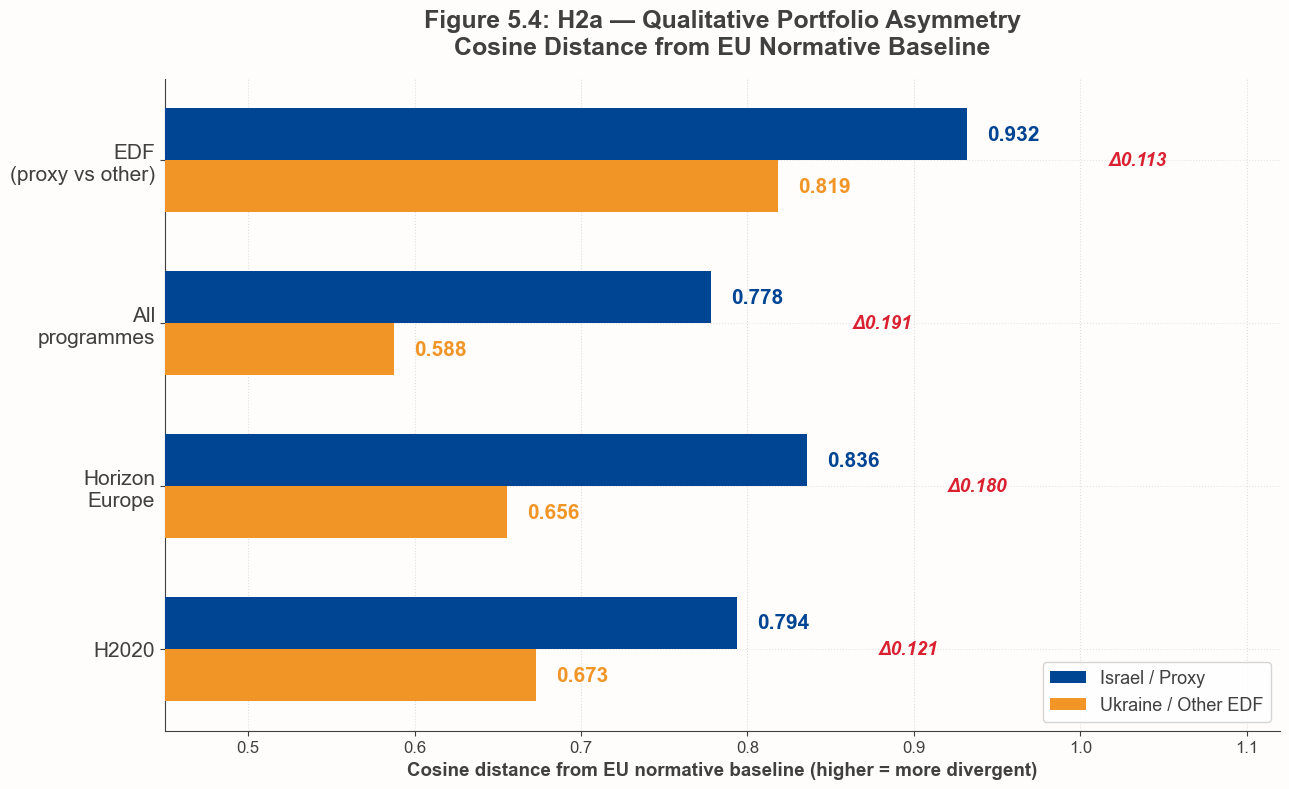

In [ ]:

EU_BLUE = '#004494'
EU_WARN = '#F29527'
EU_G100 = '#404040'
EU_G75 = '#707070'

BG_COLOR = '#FEFDFB'  # matches poster background tone
plt.rcParams.update({'font.family': 'Arial', 'figure.facecolor': BG_COLOR})

# ── Compute results FRESH, every run — no hardcoded values, no stale cache ────
results = run_h2a_analysis(israel, ukraine, edf_proxy, edf_other, verbose=True)

categories = ['H2020', 'Horizon\nEurope', 'All\nprogrammes', 'EDF\n(proxy vs other)']
keymap     = ['H2020', 'Horizon', 'All programmes', 'EDF (proxy/other)']

israel_vals  = [results[k]['Israel']  for k in keymap]
ukraine_vals = [results[k]['Ukraine'] for k in keymap]
deltas       = [results[k]['Delta']   for k in keymap]

print("\nValues used in Figure 5.4a (freshly computed this run):")
for cat, il, ua, d in zip(keymap, israel_vals, ukraine_vals, deltas):
    print(f"  {cat:<20} Israel={il:.3f}  Ukraine={ua:.3f}  Delta={d:.3f}")

y = np.arange(len(categories))
height = 0.32

fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

b1 = ax.barh(y + height/2, israel_vals, height, color=EU_BLUE, label='Israel / Proxy', zorder=3)
b2 = ax.barh(y - height/2, ukraine_vals, height, color=EU_WARN, label='Ukraine / Other EDF', zorder=3)

for yi, v in zip(y, israel_vals):
    ax.text(v + 0.012, yi + height/2, f'{v:.3f}', va='center', ha='left',
              fontsize=15, fontweight='bold', color=EU_BLUE)
for yi, v in zip(y, ukraine_vals):
    ax.text(v + 0.012, yi - height/2, f'{v:.3f}', va='center', ha='left',
              fontsize=15, fontweight='bold', color=EU_WARN)
for yi, (il, ua, d) in enumerate(zip(israel_vals, ukraine_vals, deltas)):
    ax.text(max(il, ua) + 0.085, yi, f'\u0394{d:.3f}', va='center', ha='left',
              fontsize=13.5, fontweight='bold', style='italic', color='#DA2131')

ax.set_yticks(y)
ax.set_yticklabels(categories, fontsize=15)
ax.set_xlabel('Cosine distance from EU normative baseline (higher = more divergent)',
              fontsize=13.5, fontweight='bold')
ax.set_xlim(0.45, 1.12)
ax.set_title('Figure 5.4: H2a \u2014 Qualitative Portfolio Asymmetry\n'
             'Cosine Distance from EU Normative Baseline',
             fontsize=18, fontweight='bold', color=EU_G100, pad=18)
ax.legend(loc='lower right', fontsize=13, frameon=True)
ax.grid(axis='x', linestyle=':', alpha=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)
out = SAVE_PATH + 'figure_5_4a_panelA_corrected.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

EU normative baseline corpus: 1878 tokens (Horizon Europe Reg. + COM(2024)26 + EDIS, verbatim, Appendix A)
Excluded as generic (Israel): ['high', 'new', 'using']
Excluded as generic (Ukraine): []

Israel-distinctive terms (top 12):
  cancer: 0.1917
  cell: 0.1547
  treatment: 0.1312
  platform: 0.1261
  quantum: 0.1211
  learning: 0.1026
  disease: 0.0925
  health: 0.0925
  brain: 0.0884
  therapy: 0.0874
  detection: 0.0841
  networks: 0.0841

Ukraine-distinctive terms (top 12):
  europe: 0.2619
  energy: 0.2469
  innovation: 0.2432
  sustainable: 0.2198
  digital: 0.1988
  ukraine: 0.1265
  eu: 0.1029
  resilient: 0.0903
  building: 0.0843
  hydrogen: 0.0843
  green: 0.0663
  transformation: 0.0663


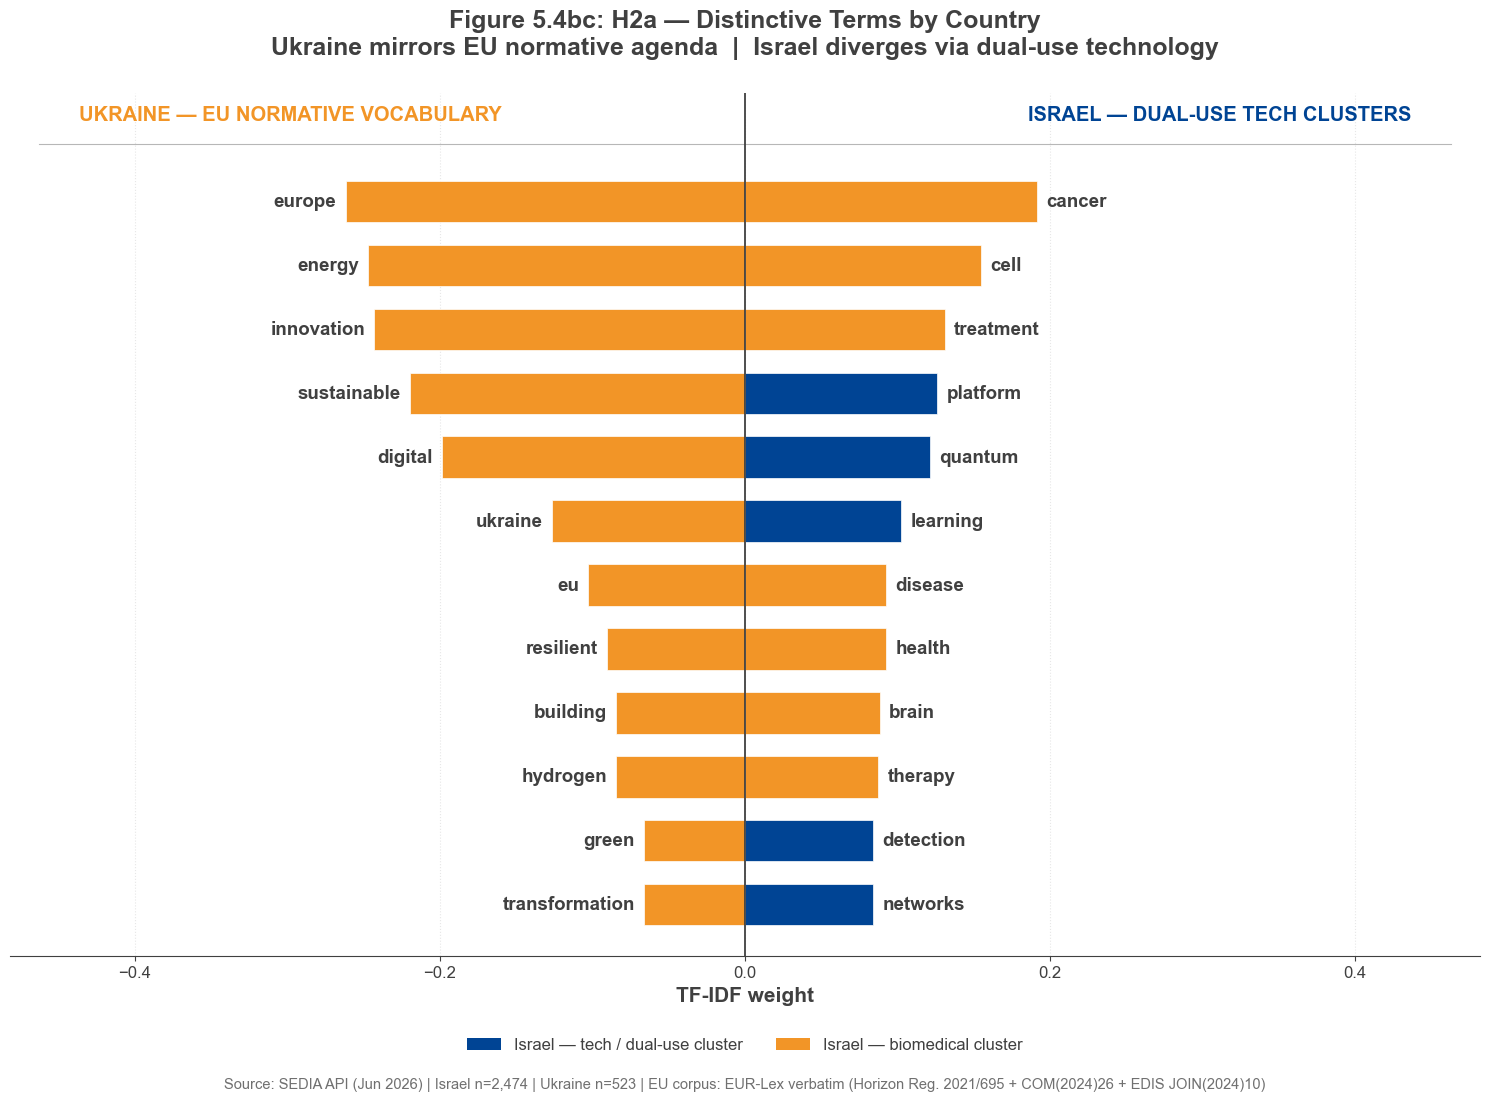

In [ ]:
from matplotlib.patches import Patch
from sklearn.feature_extraction.text import TfidfVectorizer


EU_BLUE = '#004494'; EU_WARN = '#F29527'; EU_G100 = '#404040'; EU_G75 = '#707070'; EU_WHITE = '#FFFFFF'
plt.rcParams.update({'font.family': 'Arial', 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': EU_WHITE, 'axes.facecolor': EU_WHITE})

SAVE = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE, exist_ok=True)

eu_corpus = build_eu_normative_corpus(verbose=True)
il_corpus = ' '.join(israel['metadata_title'].tolist())
ua_corpus = ' '.join(ukraine['metadata_title'].tolist())

vec = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))
tfidf = vec.fit_transform([eu_corpus, il_corpus, ua_corpus])
features = vec.get_feature_names_out()
iv = tfidf[1].toarray()[0]
uv = tfidf[2].toarray()[0]

GENERIC_STOPWORDS = {'using', 'new', 'high', 'based', 'advanced', 'novel',
                      'innovative', 'development', 'system', 'approach'}

il_dist_raw = sorted([(w, iv[i], uv[i]) for i, w in enumerate(features)
                       if iv[i] > 0.05 and iv[i] > uv[i] * 2], key=lambda x: -x[1])
il_dist = [t for t in il_dist_raw if t[0] not in GENERIC_STOPWORDS]
top_il = il_dist[:12]

ua_dist_raw = sorted([(w, uv[i], iv[i]) for i, w in enumerate(features)
                       if uv[i] > 0.05 and uv[i] > iv[i] * 2], key=lambda x: -x[1])
ua_dist = [t for t in ua_dist_raw if t[0] not in GENERIC_STOPWORDS]
top_ua = ua_dist[:12]

print(f"Excluded as generic (Israel): {[t[0] for t in il_dist_raw if t[0] in GENERIC_STOPWORDS]}")
print(f"Excluded as generic (Ukraine): {[t[0] for t in ua_dist_raw if t[0] in GENERIC_STOPWORDS]}")
print("\nIsrael-distinctive terms (top 12):")
for w, ilv, uav in top_il:
    print(f"  {w}: {ilv:.4f}")
print("\nUkraine-distinctive terms (top 12):")
for w, uav, ilv in top_ua:
    print(f"  {w}: {uav:.4f}")


bio = {'cancer', 'cell', 'treatment', 'disease', 'brain', 'therapy', 'patients', 'health'}
israel_terms  = [t[0] for t in top_il]
israel_w      = [t[1] for t in top_il]
israel_colors = [EU_WARN if t in bio else EU_BLUE for t in israel_terms]

ukraine_terms = [t[0] for t in top_ua]
ukraine_w     = [t[1] for t in top_ua]

n = max(len(israel_terms), len(ukraine_terms))
y_pos = np.arange(n)

fig, ax = plt.subplots(figsize=(15, 11))

uk_w_arr = np.array(ukraine_w + [0] * (n - len(ukraine_w)))
uk_terms_arr = ukraine_terms + [''] * (n - len(ukraine_terms))
ax.barh(y_pos, -uk_w_arr, color=EU_WARN, height=0.65, edgecolor='white', linewidth=0.5, zorder=3)

il_w_arr = np.array(israel_w + [0] * (n - len(israel_w)))
il_terms_arr = israel_terms + [''] * (n - len(israel_terms))
il_colors_arr = israel_colors + [EU_WARN] * (n - len(israel_colors))
ax.barh(y_pos, il_w_arr, color=il_colors_arr, height=0.65, edgecolor='white', linewidth=0.5, zorder=3)

max_w = max(uk_w_arr.max(), il_w_arr.max()) * 1.15
for i in range(n):
    if uk_terms_arr[i]:
        ax.text(-uk_w_arr[i] - max_w * 0.02, y_pos[i], uk_terms_arr[i],
                ha='right', va='center', fontsize=13.5, fontweight='bold', color=EU_G100)
    if il_terms_arr[i]:
        ax.text(il_w_arr[i] + max_w * 0.02, y_pos[i], il_terms_arr[i],
                ha='left', va='center', fontsize=13.5, fontweight='bold', color=EU_G100)

ax.axvline(0, color=EU_G100, lw=1.3, zorder=4)
ax.set_xlim(-max_w * 1.6, max_w * 1.6)
ax.set_ylim(-1.7, n - 0.2)
ax.invert_yaxis()
ax.set_yticks([])
ax.set_xlabel('TF-IDF weight', fontsize=15, fontweight='bold')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis='x', labelsize=12)

ax.text(-max_w * 1.45, -1.35, 'UKRAINE — EU NORMATIVE VOCABULARY', fontsize=14.5,
        fontweight='bold', color=EU_WARN, ha='left', va='center')
ax.text(max_w * 1.45, -1.35, 'ISRAEL — DUAL-USE TECH CLUSTERS', fontsize=14.5,
        fontweight='bold', color=EU_BLUE, ha='right', va='center')
ax.axhline(-0.9, color=EU_G75, lw=0.8, alpha=0.5, xmin=0.02, xmax=0.98)

legend_elems = [
    Patch(facecolor=EU_BLUE, label='Israel — tech / dual-use cluster'),
    Patch(facecolor=EU_WARN, label='Israel — biomedical cluster'),
]
ax.legend(handles=legend_elems, loc='lower center', bbox_to_anchor=(0.5, -0.13),
          ncol=2, fontsize=12, frameon=False)

ax.set_title('Figure 5.4bc: H2a — Distinctive Terms by Country\n'
             'Ukraine mirrors EU normative agenda  |  Israel diverges via dual-use technology',
             fontsize=18, fontweight='bold', color=EU_G100, pad=28)

fig.text(0.5, 0.005,
    f'Source: SEDIA API (Jun 2026) | Israel n={len(israel):,} | Ukraine n={len(ukraine):,} | '
    f'EU corpus: EUR-Lex verbatim (Horizon Reg. 2021/695 + COM(2024)26 + EDIS JOIN(2024)10)',
    ha='center', fontsize=10.5, color=EU_G75)

plt.tight_layout(rect=[0, 0.02, 1, 1])
out = SAVE + 'figure_5_4bc_diverging_FINAL.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU_WHITE)
plt.show()

EDF proxy projects: 18 | EDF other projects: 234

Pooled proxy-unique vocabulary: 14 distinct terms, 16 total occurrences across 18 proxy titles
Same 14 terms in 234 other EDF titles: 0 occurrences

Top intensity-ratio shared terms:
      term  proxy_n  other_n  proxy_pct  other_pct    ratio
  armoured        2        3  11.111111   1.282051 8.666667
operations        3        5  16.666667   2.136752 7.800000
  tactical        2        7  11.111111   2.991453 3.714286
  military        3       16  16.666667   6.837607 2.437500


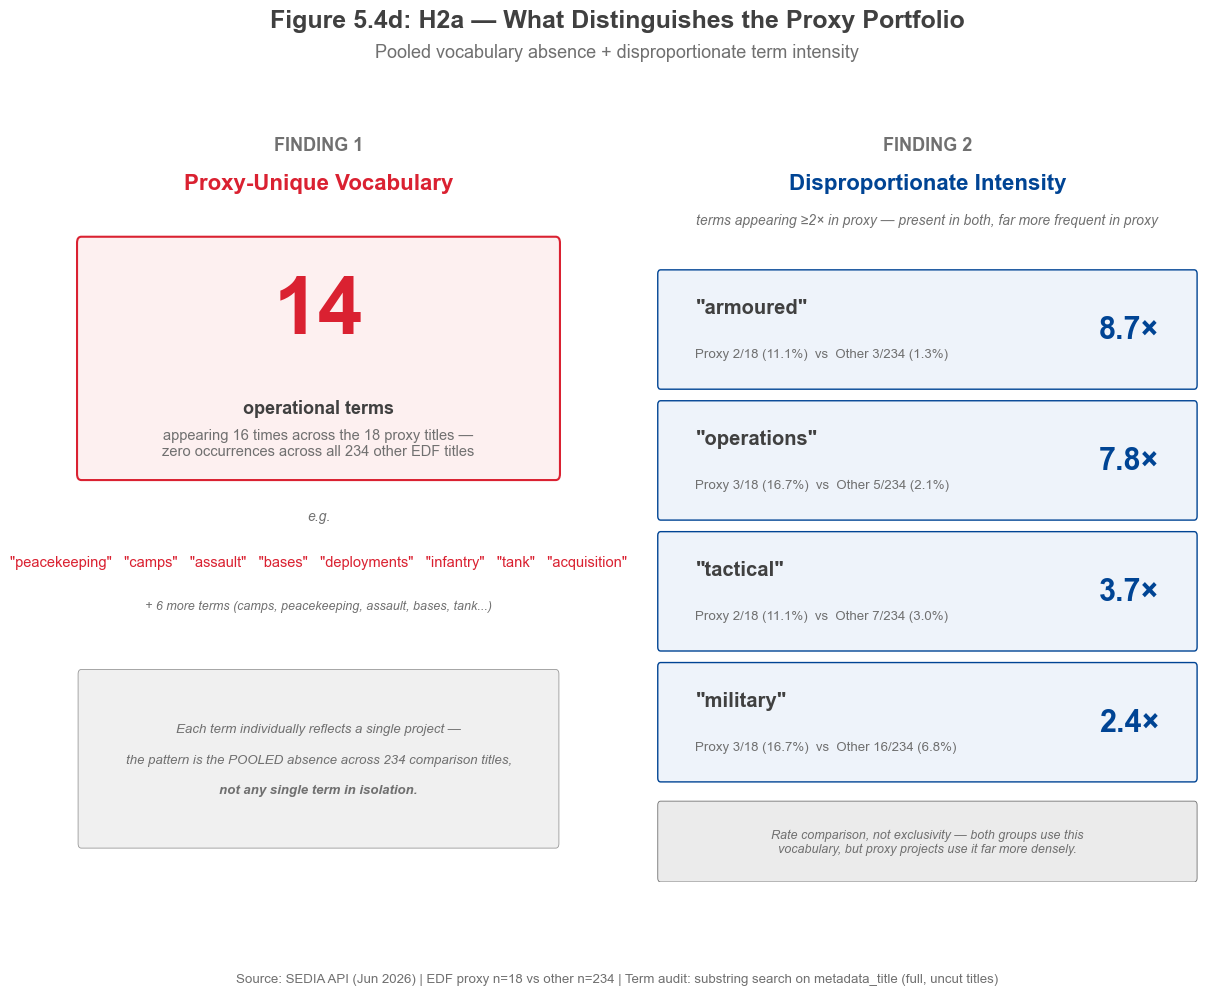

In [ ]:
class EU:
    BLUE = '#004494'; ERROR = '#DA2131'; WARNING = '#F29527'
    SUCCESS = '#467A39'; GREY_100 = '#404040'; GREY_75 = '#707070'
    GREY_10 = '#EBEBEB'; WHITE = '#FFFFFF'

plt.rcParams.update({'font.family': 'Arial', 'figure.facecolor': EU.WHITE})

SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)


proxy_total = len(edf_proxy)
other_total = len(edf_other)
print(f"EDF proxy projects: {proxy_total} | EDF other projects: {other_total}")

TERMS_OF_INTEREST = [
    'assault', 'peacekeeping', 'camps', 'bases', 'deployment', 'deployments',
    'combat', 'warfare', 'drone', 'munition', 'military', 'tactical',
    'armour', 'armoured', 'infantry', 'tank', 'explosive', 'explosives',
    'target', 'targeting', 'acquisition', 'missile', 'troops',
    'special operations', 'reconnaissance', 'convoy', 'penetration',
    'satellite', 'uav', 'security', 'lifesaving', 'covert', 'command',
    'forces', 'operations'
]

rows = []
for term in TERMS_OF_INTEREST:
    pm = edf_proxy[edf_proxy['metadata_title'].str.contains(term, case=False, na=False)]
    om = edf_other[edf_other['metadata_title'].str.contains(term, case=False, na=False)]
    rows.append({'term': term, 'proxy_n': len(pm), 'other_n': len(om)})
res = pd.DataFrame(rows)

unique_terms = res[(res.proxy_n > 0) & (res.other_n == 0)].sort_values('proxy_n', ascending=False)
shared_terms = res[(res.proxy_n > 0) & (res.other_n > 0)].copy()

VARIANT_GROUPS = [
    {'armour', 'armoured'},
    {'deployment', 'deployments'},
    {'explosive', 'explosives'},
]

def dedupe_variants(term_df):
    keep_mask = pd.Series(True, index=term_df.index)
    for group in VARIANT_GROUPS:
        present = term_df[term_df.term.isin(group)]
        if len(present) > 1:
            longest = present.loc[present.term.str.len().idxmax(), 'term']
            for idx, row in present.iterrows():
                if row.term != longest:
                    keep_mask[idx] = False
    return term_df[keep_mask]

unique_terms = dedupe_variants(unique_terms).sort_values('proxy_n', ascending=False)
shared_terms = dedupe_variants(shared_terms)
shared_terms['proxy_pct'] = 100 * shared_terms.proxy_n / proxy_total
shared_terms['other_pct'] = 100 * shared_terms.other_n / other_total
shared_terms['ratio'] = shared_terms.proxy_pct / shared_terms.other_pct


shared_terms = shared_terms[shared_terms.proxy_n >= 2].sort_values('ratio', ascending=False)

n_unique_terms = len(unique_terms)
n_unique_occurrences = unique_terms.proxy_n.sum()

print(f"\nPooled proxy-unique vocabulary: {n_unique_terms} distinct terms, "
      f"{n_unique_occurrences} total occurrences across {proxy_total} proxy titles")
print(f"Same {n_unique_terms} terms in {other_total} other EDF titles: 0 occurrences")
print("\nTop intensity-ratio shared terms:")
print(shared_terms[['term', 'proxy_n', 'other_n', 'proxy_pct', 'other_pct', 'ratio']]
      .head(6).to_string(index=False))


fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.1)

ax1 = fig.add_subplot(gs[0])
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10); ax1.axis('off')

ax1.text(5, 9.5, 'FINDING 1', ha='center', fontsize=13, fontweight='bold', color=EU.GREY_75)
ax1.text(5, 9.0, 'Proxy-Unique Vocabulary', ha='center', fontsize=16,
          fontweight='bold', color=EU.ERROR)

ax1.add_patch(FancyBboxPatch((0.5, 5.3), 9, 3.0, boxstyle="round,pad=0.08",
              facecolor='#FDF0F0', edgecolor=EU.ERROR, lw=1.5))
ax1.text(5, 7.4, f'{n_unique_terms}', ha='center', va='center', fontsize=58,
          fontweight='bold', color=EU.ERROR)
ax1.text(5, 6.15, 'operational terms', ha='center', va='center', fontsize=13,
          color=EU.GREY_100, fontweight='bold')
ax1.text(5, 5.7, f'appearing {n_unique_occurrences} times across the {proxy_total} proxy titles —\n'
                   f'zero occurrences across all {other_total} other EDF titles',
          ha='center', va='center', fontsize=10.5, color=EU.GREY_75)

examples = unique_terms.term.tolist()[:8]
ax1.text(5, 4.7, 'e.g.', ha='center', fontsize=10, color=EU.GREY_75, style='italic')
chip_text = '   '.join([f'"{t}"' for t in examples])
ax1.text(5, 4.15, chip_text, ha='center', va='center', fontsize=10.5, color=EU.ERROR, wrap=True)
ax1.text(5, 3.55, f'+ {n_unique_terms - len(examples)} more terms '
                   f'(camps, peacekeeping, assault, bases, tank...)',
          ha='center', fontsize=9, color=EU.GREY_75, style='italic')

ax1.add_patch(FancyBboxPatch((0.5, 0.5), 9, 2.2, boxstyle="round,pad=0.06",
              facecolor=EU.GREY_10, edgecolor=EU.GREY_75, lw=0.6, alpha=0.7))
ax1.text(5, 1.95, 'Each term individually reflects a single project —', ha='center',
          fontsize=9.5, color=EU.GREY_75, style='italic')
ax1.text(5, 1.55, 'the pattern is the POOLED absence across 234 comparison titles,',
          ha='center', fontsize=9.5, color=EU.GREY_75, style='italic')
ax1.text(5, 1.15, 'not any single term in isolation.', ha='center',
          fontsize=9.5, color=EU.GREY_75, style='italic', fontweight='bold')

ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10); ax2.axis('off')

ax2.text(5, 9.5, 'FINDING 2', ha='center', fontsize=13, fontweight='bold', color=EU.GREY_75)
ax2.text(5, 9.0, 'Disproportionate Intensity', ha='center', fontsize=16,
          fontweight='bold', color=EU.BLUE)
ax2.text(5, 8.55, 'terms appearing \u22652\u00d7 in proxy — present in both, far more frequent in proxy',
          ha='center', fontsize=10, color=EU.GREY_75, style='italic')

top4 = shared_terms.head(4)
card_h = 1.45
for i, (_, row) in enumerate(top4.iterrows()):
    y_top = 7.9 - i * (card_h + 0.25)
    y_c = y_top - card_h / 2
    ax2.add_patch(FancyBboxPatch((0.4, y_top - card_h), 9.2, card_h,
                  boxstyle="round,pad=0.05", facecolor='#EEF3FA', edgecolor=EU.BLUE, lw=1.0))
    ax2.text(1.0, y_c + 0.28, f'"{row.term}"', fontsize=14.5, fontweight='bold',
              color=EU.GREY_100, ha='left', va='center')
    ax2.text(1.0, y_c - 0.32, f'Proxy {row.proxy_n}/{proxy_total} ({row.proxy_pct:.1f}%)  vs  '
                                f'Other {row.other_n}/{other_total} ({row.other_pct:.1f}%)',
              fontsize=9.5, color=EU.GREY_75, ha='left', va='center')
    ax2.text(9.0, y_c, f'{row.ratio:.1f}\u00d7', fontsize=22, fontweight='bold',
              color=EU.BLUE, ha='right', va='center')

ax2.add_patch(FancyBboxPatch((0.4, 0.05), 9.2, 0.95, boxstyle="round,pad=0.05",
              facecolor=EU.GREY_10, edgecolor=EU.GREY_75, lw=0.6))
ax2.text(5, 0.52, 'Rate comparison, not exclusivity — both groups use this\n'
                  'vocabulary, but proxy projects use it far more densely.',
          ha='center', va='center', fontsize=9, color=EU.GREY_75, style='italic')

fig.text(0.5, 0.965, 'Figure 5.4d: H2a \u2014 What Distinguishes the Proxy Portfolio',
          ha='center', fontsize=18, fontweight='bold', color=EU.GREY_100)
fig.text(0.5, 0.935, 'Pooled vocabulary absence + disproportionate term intensity',
          ha='center', fontsize=13, color=EU.GREY_75)

fig.text(0.5, 0.01,
    'Source: SEDIA API (Jun 2026) | EDF proxy n=18 vs other n=234 | '
    'Term audit: substring search on metadata_title (full, uncut titles)',
    ha='center', fontsize=9.5, color=EU.GREY_75)

plt.tight_layout(rect=[0, 0.02, 1, 0.91])
out = SAVE_PATH + 'figure_5_4d_military_terms_v3.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()

### 6.1 Statistical Validation

**TF-IDF / Cosine Distance (H2a):**
1. **Permutation test** (n=2,000): observed Δ vs. null distribution from random splits
2. **Split-half placebo**: Israel vs. itself (noise floor estimate)
3. **Parameter sensitivity**: 6 configurations (max_features × ngram)

**Welch's t-test (H1b):**
4. **Variance ratio check**: justifies Welch over Student's t-test
5. **Mann-Whitney U**: non-parametric cross-check
6. **Cohen's d**: effect size, distinguishes "no effect" from "underpowered"

In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

eu_corpus = build_eu_normative_corpus(verbose=True)
il_corpus = ' '.join(israel['metadata_title'].tolist())
ua_corpus = ' '.join(ukraine['metadata_title'].tolist())

print(f"Israel n={len(israel)} | Ukraine n={len(ukraine)}")


def cosine_dist_joint(corpus_a, corpus_b, baseline, max_features=1000, ngram_range=(1, 2)):
    """Fits TF-IDF jointly on [baseline, corpus_a, corpus_b] (same IDF weights
    for both comparisons, matching figure_5_4a_distance_CORRECTED.py)."""
    vec = TfidfVectorizer(stop_words='english', max_features=max_features, ngram_range=ngram_range)
    tfidf = vec.fit_transform([baseline, corpus_a, corpus_b])
    sim = cosine_similarity(tfidf[0:1], tfidf[1:])[0]
    return 1 - sim[0], 1 - sim[1]


def cosine_dist(corpus_x, baseline, max_features=1000, ngram_range=(1, 2)):
    """Single-corpus distance, used only for the split-half placebo test."""
    vec = TfidfVectorizer(stop_words='english', max_features=max_features, ngram_range=ngram_range)
    tfidf = vec.fit_transform([baseline, corpus_x])
    sim = cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
    return 1 - sim


observed_il, observed_ua = cosine_dist_joint(il_corpus, ua_corpus, eu_corpus)
observed_delta = observed_il - observed_ua
print(f"\nObserved (All programmes): Israel={observed_il:.4f} | Ukraine={observed_ua:.4f} | "
      f"Delta={observed_delta:.4f}")

# A1 — PERMUTATION TEST
print("\n" + "=" * 70)
print("A1. PERMUTATION TEST — All Programmes (Israel vs Ukraine)")
print("=" * 70)
print("H0: Delta observed could arise from randomly splitting the combined")
print(f"    pool into a {len(israel)}-project group and a {len(ukraine)}-project group.")

all_titles = israel['metadata_title'].tolist() + ukraine['metadata_title'].tolist()
n_il, n_ua = len(israel), len(ukraine)
n_perm = 2000  

rng = np.random.default_rng(42)
perm_deltas = []
for i in range(n_perm):
    shuffled = rng.permutation(all_titles)
    grp_a = ' '.join(shuffled[:n_il])
    grp_b = ' '.join(shuffled[n_il:n_il + n_ua])
    d_a, d_b = cosine_dist_joint(grp_a, grp_b, eu_corpus, max_features=500)
    perm_deltas.append(d_a - d_b)
    if (i + 1) % 500 == 0:
        print(f"  {i + 1}/{n_perm} permutations done...")

perm_deltas = np.array(perm_deltas)
p_value = np.mean(np.abs(perm_deltas) >= np.abs(observed_delta))
percentile = stats.percentileofscore(perm_deltas, observed_delta)

print(f"\nPermutation null distribution: mean={perm_deltas.mean():.4f}, std={perm_deltas.std():.4f}")
print(f"Observed Delta={observed_delta:.4f} sits at the {percentile:.1f}th percentile")
print(f"Two-tailed p-value = {p_value:.4f}")
print(f"{'SIGNIFICANT' if p_value < 0.05 else 'NOT significant at alpha=0.05'}")


# A2 — SPLIT-HALF PLACEBO TEST 
print("\n" + "=" * 70)
print("A2. SPLIT-HALF PLACEBO TEST")
print("=" * 70)
print("Splitting Israel's own titles randomly in half — distance between")
print("the two halves should be small relative to the observed Delta.")

il_titles = israel['metadata_title'].tolist()
rng2 = np.random.default_rng(7)
shuffled_il = rng2.permutation(il_titles)
half_a = ' '.join(shuffled_il[:len(shuffled_il) // 2])
half_b = ' '.join(shuffled_il[len(shuffled_il) // 2:])
placebo_dist = cosine_dist(half_a, half_b, max_features=1000)
print(f"Split-half distance (Israel vs itself): {placebo_dist:.4f}")
print(f"For reference, observed Israel-Ukraine Delta = {observed_delta:.4f}")
print(f"{'PASS — noise floor well below observed Delta' if placebo_dist < observed_delta * 0.6 else 'CAUTION — noise floor is a substantial fraction of observed Delta, report honestly'}")

# A3 — PARAMETER SENSITIVITY
print("\n" + "=" * 70)
print("A3. PARAMETER SENSITIVITY")
print("=" * 70)
configs = [
    (500, (1, 1)), (500, (1, 2)),
    (1000, (1, 1)), (1000, (1, 2)),
    (2000, (1, 1)), (2000, (1, 2)),
]
print(f"{'max_features':>13} {'ngram_range':>12} {'Israel':>8} {'Ukraine':>8} {'Delta':>8}")
for mf, ng in configs:
    d_il, d_ua = cosine_dist_joint(il_corpus, ua_corpus, eu_corpus, max_features=mf, ngram_range=ng)
    print(f"{mf:>13} {str(ng):>12} {d_il:>8.4f} {d_ua:>8.4f} {d_il - d_ua:>8.4f}")

# PART B — WELCH'S T-TEST VALIDATION (H1b)
print("\n" + "=" * 70)
print("B. WELCH'S T-TEST VALIDATION (H1b — Temporal Elasticity)")
print("=" * 70)

years = list(range(2019, 2025))
il_series = np.array([il_annual[y] for y in years])
ua_series = np.array([ua_annual[y] for y in years])

il_pre, il_post = il_series[:3], il_series[3:]
ua_pre, ua_post = ua_series[:3], ua_series[3:]

print(f"Israel pre (2019-21): {il_pre} | post (2022-24): {il_post}")
print(f"Ukraine pre (2019-21): {ua_pre} | post (2022-24): {ua_post}")

# B1 — Variance ratio 
print("\n--- B1. Variance ratio check ---")
for name, pre, post in [("Israel", il_pre, il_post), ("Ukraine", ua_pre, ua_post)]:
    var_pre, var_post = np.var(pre, ddof=1), np.var(post, ddof=1)
    ratio = max(var_pre, var_post) / min(var_pre, var_post) if min(var_pre, var_post) > 0 else np.inf
    f_stat, f_p = stats.levene(pre, post)
    print(f"{name}: var(pre)={var_pre:.1f}, var(post)={var_post:.1f}, ratio={ratio:.2f}x | "
          f"Levene's test p={f_p:.4f} "
          f"{'(unequal variance — Welch justified)' if f_p < 0.05 else '(no strong evidence of inequality, but Welch still safe default)'}")

# B2 — Welch's t-test + Mann-Whitney U in parallel
print("\n--- B2. Welch's t-test vs Mann-Whitney U ---")
for name, pre, post in [("Israel", il_pre, il_post), ("Ukraine", ua_pre, ua_post)]:
    t_stat, t_p = stats.ttest_ind(pre, post, equal_var=False)  # Welch
    try:
        u_stat, u_p = stats.mannwhitneyu(pre, post, alternative='two-sided')
    except ValueError:
        u_stat, u_p = np.nan, np.nan
    agree = ("AGREE (both n.s.)" if (t_p >= 0.05 and (np.isnan(u_p) or u_p >= 0.05)) else
             "AGREE (both sig.)" if (t_p < 0.05 and not np.isnan(u_p) and u_p < 0.05) else
             "DISAGREE — flag in limitations")
    print(f"{name}: Welch t={t_stat:.3f}, p={t_p:.4f} | Mann-Whitney U={u_stat}, p={u_p:.4f} | {agree}")

# B3 — Cohen's d (effect size)
print("\n--- B3. Cohen's d (effect size) ---")
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(((n1 - 1) * np.var(a, ddof=1) + (n2 - 1) * np.var(b, ddof=1)) / (n1 + n2 - 2))
    return (np.mean(b) - np.mean(a)) / pooled_std if pooled_std > 0 else np.nan

for name, pre, post in [("Israel", il_pre, il_post), ("Ukraine", ua_pre, ua_post)]:
    d = cohens_d(pre, post)
    magnitude = "negligible" if abs(d) < 0.2 else "small" if abs(d) < 0.5 else "medium" if abs(d) < 0.8 else "large"
    print(f"{name}: Cohen's d = {d:.3f} ({magnitude} effect)")

print("\n" + "=" * 70)
print("=" * 70)

EU normative baseline corpus: 1878 tokens (Horizon Europe Reg. + COM(2024)26 + EDIS, verbatim, Appendix A)
Israel n=2474 | Ukraine n=523

Observed (All programmes): Israel=0.7783 | Ukraine=0.5877 | Delta=0.1907

A1. PERMUTATION TEST — All Programmes (Israel vs Ukraine)
H0: Delta observed could arise from randomly splitting the combined
    pool into a 2474-project group and a 523-project group.
  500/2000 permutations done...
  1000/2000 permutations done...
  1500/2000 permutations done...
  2000/2000 permutations done...

Permutation null distribution: mean=-0.0168, std=0.0259
Observed Delta=0.1907 sits at the 100.0th percentile
Two-tailed p-value = 0.0000
SIGNIFICANT

A2. SPLIT-HALF PLACEBO TEST
Splitting Israel's own titles randomly in half — distance between
the two halves should be small relative to the observed Delta.
Split-half distance (Israel vs itself): 0.0727
For reference, observed Israel-Ukraine Delta = 0.1907
PASS — noise floor well below observed Delta

A3. PARAMETER SE

---
## 7. H2b Analysis: Proxy Entity Detection and Coordinator Capture

**Hypothesis:** Israeli EDF access operates through EU-registered proxy entities whose beneficial ownership by Israeli state-controlled corporations bypasses Article 9 eligibility checks.

**Proxy entities identified:**
- **Intracom Defense AE** (Athens, Greece) — 94.5% owned by IAI since May 2023
- **Optronic Instruments & Products N.V.** (Belgium) — Elbit Systems subsidiary

Source: FRS/DG DEFIS European Defence Fund Assessment Report No.19 (2024, updated April 2025), p.37

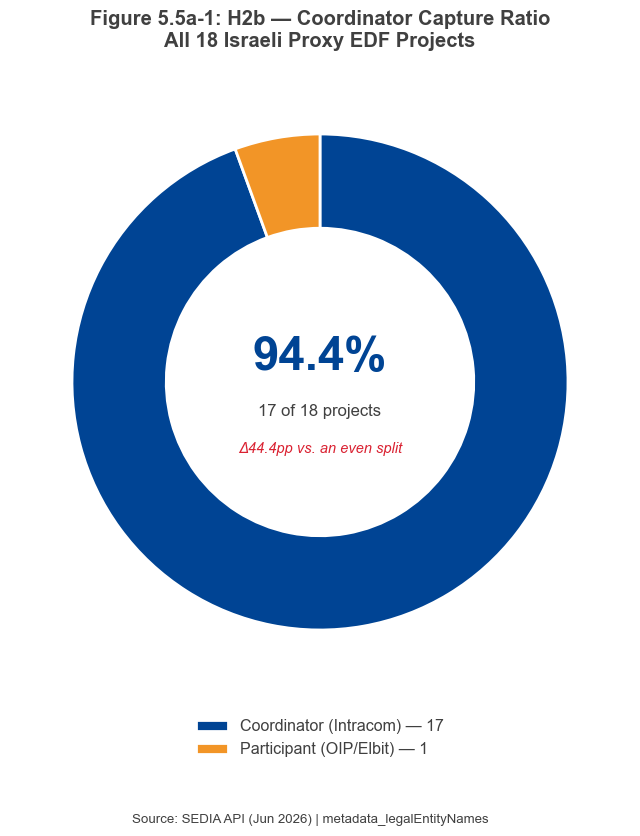

In [ ]:
class EU:
    BLUE = '#004494'; WARNING = '#F29527'; ERROR = '#DA2131'
    GREY_70 = '#404040'; WHITE = '#FFFFFF'; BLUE_120 = '#003776'

plt.rcParams.update({'font.family': 'Arial', 'text.color': EU.GREY_70})

SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)

coordinator_n, participant_n = 17, 1
total = coordinator_n + participant_n
pct_coord = coordinator_n / total * 100

fig, ax = plt.subplots(figsize=(8, 9))
ax.set_title('Figure 5.5a-1: H2b — Coordinator Capture Ratio\nAll 18 Israeli Proxy EDF Projects',
             fontsize=14.5, fontweight='bold', color=EU.GREY_70, pad=18)

wedges, _ = ax.pie(
    [coordinator_n, participant_n],
    colors=[EU.BLUE, EU.WARNING],
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.38, edgecolor='white', linewidth=2)
)

# Center text
ax.text(0, 0.10, f'{pct_coord:.1f}%', ha='center', va='center',
        fontsize=34, fontweight='bold', color=EU.BLUE)
ax.text(0, -0.12, '17 of 18 projects', ha='center', va='center',
        fontsize=12, color=EU.GREY_70)
ax.text(0, -0.27, '\u039444.4pp vs. an even split', ha='center', va='center',
        fontsize=10.5, color=EU.ERROR, style='italic')

ax.legend(
    [f'Coordinator (Intracom) \u2014 17', f'Participant (OIP/Elbit) \u2014 1'],
    loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=1,
    fontsize=11.5, frameon=False
)

fig.text(0.5, 0.015, 'Source: SEDIA API (Jun 2026) | metadata_legalEntityNames',
          ha='center', fontsize=9.5, color=EU.GREY_70)

ax.set_aspect('equal')
plt.subplots_adjust(top=0.88, bottom=0.13)
out = SAVE_PATH + 'figure_5_5a1_coordinator_donut.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()

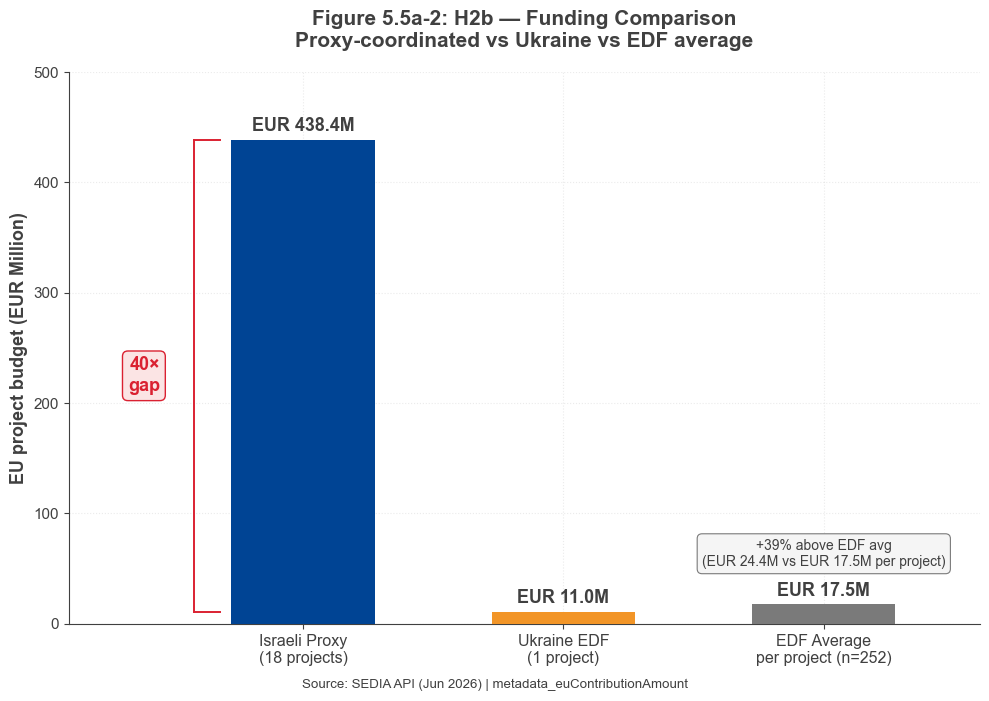

In [ ]:
class EU:
    BLUE = '#004494'; WARNING = '#F29527'; GREY_50 = '#7A7A7A'
    ERROR = '#DA2131'; GREY_70 = '#404040'; WHITE = '#FFFFFF'; BLUE_120 = '#003776'

plt.rcParams.update({'font.family': 'Arial', 'axes.edgecolor': EU.GREY_70,
    'axes.labelcolor': EU.GREY_70, 'xtick.color': EU.GREY_70, 'ytick.color': EU.GREY_70,
    'text.color': EU.GREY_70, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': ':'})

SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)

labels = ['Israeli Proxy\n(18 projects)', 'Ukraine EDF\n(1 project)', 'EDF Average\nper project (n=252)']
values = [438.4, 11.0, 17.5]
colors = [EU.BLUE, EU.WARNING, EU.GREY_50]

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_title('Figure 5.5a-2: H2b — Funding Comparison\nProxy-coordinated vs Ukraine vs EDF average',
             fontsize=15, fontweight='bold', color=EU.GREY_70, pad=18)

bars = ax.bar(labels, values, color=colors, width=0.55, zorder=3)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 8, f'EUR {v:.1f}M',
            ha='center', fontsize=13, fontweight='bold', color=EU.GREY_70)

ax.plot([-0.42, -0.42], [11.0, 438.4], color=EU.ERROR, lw=1.4, clip_on=False)
ax.plot([-0.42, -0.32], [11.0, 11.0], color=EU.ERROR, lw=1.4, clip_on=False)
ax.plot([-0.42, -0.32], [438.4, 438.4], color=EU.ERROR, lw=1.4, clip_on=False)
ax.text(-0.55, (438.4 + 11.0) / 2, '40\u00d7\ngap', ha='right', va='center',
        fontsize=13, fontweight='bold', color=EU.ERROR,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FBE4E4', edgecolor=EU.ERROR, linewidth=1))

ax.text(2, 17.5 + 35, '+39% above EDF avg\n(EUR 24.4M vs EUR 17.5M per project)',
        ha='center', fontsize=10, color=EU.GREY_70,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='#F5F5F5', edgecolor=EU.GREY_50, linewidth=0.8))

ax.set_ylabel('EU project budget (EUR Million)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 500)
ax.set_xlim(-0.9, 2.6)
ax.tick_params(axis='x', labelsize=11.5)
ax.tick_params(axis='y', labelsize=11)

fig.text(0.5, 0.01, 'Source: SEDIA API (Jun 2026) | metadata_euContributionAmount',
          ha='center', fontsize=9.5, color=EU.GREY_70)

plt.tight_layout(rect=[0, 0.02, 1, 1])
out = SAVE_PATH + 'figure_5_5a2_funding_comparison_v2.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()

In [ ]:
for var in ['df']:
    if var not in dir():
        raise NameError("'df' not found — load your main dataframe first.")

df['metadata_title'] = df['metadata_title'].fillna('').astype(str)
df['metadata_startDate'] = pd.to_datetime(df['metadata_startDate'], errors='coerce')
df['metadata_ecSignatureDate'] = pd.to_datetime(df.get('metadata_ecSignatureDate'), errors='coerce')

PROXY = ['INTRACOM DEFENSE', 'OPTRONIC INSTRUMENTS']
edf = df[df['programme'] == 'EDF'].copy()
edf['is_proxy'] = edf['metadata_legalEntityNames'].astype(str).str.upper().apply(
    lambda x: any(p in x for p in PROXY))
edf_proxy = edf[edf['is_proxy']].copy()

ACQUISITION_DATE = pd.Timestamp('2023-05-09', tz='UTC')

print("="*100)
print(f"ACQUISITION DATE: May 9, 2023")
print(f"Checking {len(edf_proxy)} EDF proxy projects' dates relative to acquisition")
print("="*100)

cols_to_check = ['metadata_title', 'metadata_startDate', 'metadata_ecSignatureDate', 'metadata_callIdentifier', 'year']
available_cols = [c for c in cols_to_check if c in edf_proxy.columns]

result = edf_proxy[available_cols].copy()
if 'metadata_startDate' in result.columns:
    result['start_vs_acquisition'] = result['metadata_startDate'].apply(
        lambda d: 'BEFORE' if pd.notna(d) and d.tz_localize(None) < ACQUISITION_DATE.tz_localize(None)
        else ('AFTER' if pd.notna(d) else 'UNKNOWN'))

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)
print(result.to_string(index=False))

print("\n" + "="*100)
print("SUMMARY")
print("="*100)
if 'start_vs_acquisition' in result.columns:
    print(result['start_vs_acquisition'].value_counts())

ACQUISITION DATE: May 9, 2023
Checking 18 EDF proxy projects' dates relative to acquisition
                                                                                      metadata_title        metadata_startDate  metadata_ecSignatureDate  metadata_callIdentifier   year start_vs_acquisition
                                                                    ArmoURed Infantry Ground Assault 2025-12-01 00:00:00+01:00 2025-12-12 00:00:00+01:00              EDF-2024-DA 2025.0                AFTER
                          Sustainable Energy Capabilities for Enhanced Military Camps and Operations 2025-11-01 00:00:00+01:00 2025-12-12 00:00:00+01:00              EDF-2024-DA 2025.0                AFTER
                                                  5G Communications for Peacekeeping and Defence 2.0 2025-12-01 00:00:00+01:00 2025-12-12 00:00:00+01:00              EDF-2024-DA 2025.0                AFTER
                                      Advanced capabilities & Certification for Tact

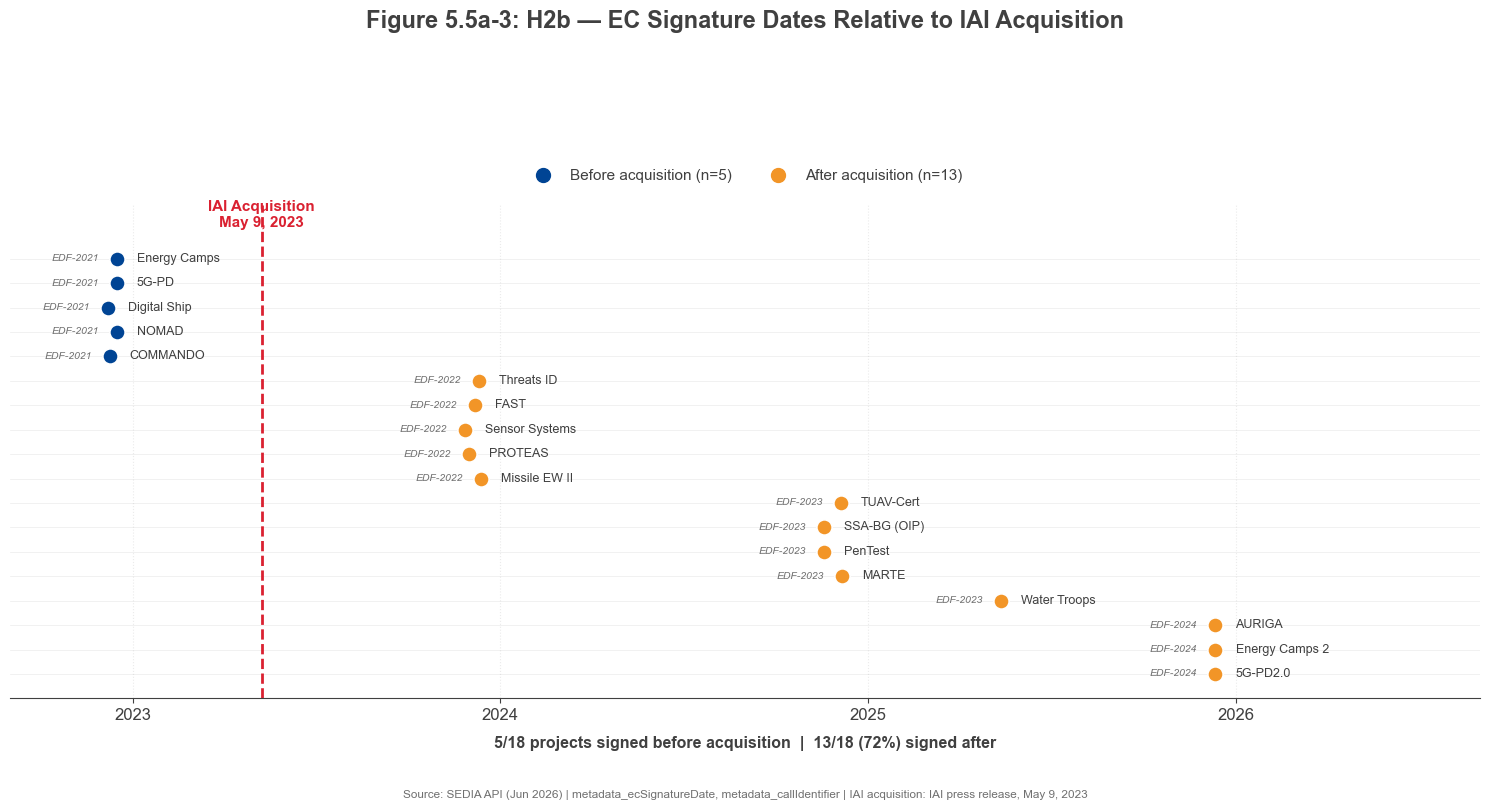

In [ ]:
class EU:
    BLUE='#004494'; WARNING='#F29527'; ERROR='#DA2131'; GREY_100='#404040'; GREY_75='#707070'; GREY_10='#EBEBEB'

plt.rcParams.update({'font.family':'Arial', 'figure.facecolor':'white'})

ACQ_DATE = datetime(2023, 5, 9)

projects = [
    (datetime(2022,12,16), "Energy Camps", "EDF-2021"),
    (datetime(2022,12,16), "5G-PD", "EDF-2021"),
    (datetime(2022,12,7),  "Digital Ship", "EDF-2021"),
    (datetime(2022,12,16), "NOMAD", "EDF-2021"),
    (datetime(2022,12,9),  "COMMANDO", "EDF-2021"),
    (datetime(2023,12,11), "Threats ID", "EDF-2022"),
    (datetime(2023,12,7),  "FAST", "EDF-2022"),
    (datetime(2023,11,27), "Sensor Systems", "EDF-2022"),
    (datetime(2023,12,1),  "PROTEAS", "EDF-2022"),
    (datetime(2023,12,13), "Missile EW II", "EDF-2022"),
    (datetime(2024,12,5),  "TUAV-Cert", "EDF-2023"),
    (datetime(2024,11,18), "SSA-BG (OIP)", "EDF-2023"),
    (datetime(2024,11,18), "PenTest", "EDF-2023"),
    (datetime(2024,12,6),  "MARTE", "EDF-2023"),
    (datetime(2025,5,13),  "Water Troops", "EDF-2023"),
    (datetime(2025,12,12), "AURIGA", "EDF-2024"),
    (datetime(2025,12,12), "Energy Camps 2", "EDF-2024"),
    (datetime(2025,12,12), "5G-PD2.0", "EDF-2024"),
]

fig, ax = plt.subplots(figsize=(15, 8))

y_positions = list(range(len(projects), 0, -1))
colors = [EU.BLUE if d < ACQ_DATE else EU.WARNING for d, _, _ in projects]

from collections import defaultdict
date_groups = defaultdict(list)
for i, (date, label, call) in enumerate(projects):
    date_groups[date].append(i)

for (date, label, call), y, color in zip(projects, y_positions, colors):
    ax.plot(date, y, 'o', color=color, markersize=11, zorder=3,
              markeredgecolor='white', markeredgewidth=1.2)
    ax.text(mdates.date2num(date) + 20, y, f'{label}', fontsize=9, va='center',
              ha='left', color=EU.GREY_100)
    ax.text(mdates.date2num(date) - 18, y, call, fontsize=7.5, va='center',
              ha='right', color=EU.GREY_75, style='italic')

ax.axvline(ACQ_DATE, color=EU.ERROR, lw=2, linestyle='--', zorder=2)
ax.text(ACQ_DATE, len(projects)+1.3, 'IAI Acquisition\nMay 9, 2023', ha='center',
          fontsize=11, fontweight='bold', color=EU.ERROR)

for y in y_positions:
    ax.axhline(y, color=EU.GREY_10, lw=0.5, zorder=1)

ax.set_xlim(datetime(2022,9,1), datetime(2026,9,1))
ax.set_ylim(0, len(projects)+2.2)
ax.set_yticks([])
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', labelsize=12)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.set_title('')

ax.plot([], [], 'o', color=EU.BLUE, markersize=10, label='Before acquisition (n=5)')
ax.plot([], [], 'o', color=EU.WARNING, markersize=10, label='After acquisition (n=13)')
ax.legend(loc='upper center', fontsize=11, frameon=False, ncol=2,
          bbox_to_anchor=(0.5, 1.10))

fig.suptitle('Figure 5.5a-3: H2b \u2014 EC Signature Dates Relative to IAI Acquisition',
              fontsize=17, fontweight='bold', color=EU.GREY_100, y=0.99)

ax.text(0.5, -0.1, '5/18 projects signed before acquisition  |  13/18 (72%) signed after',
          ha='center', fontsize=11.5, fontweight='bold', color=EU.GREY_100,
          transform=ax.transAxes)

fig.text(0.5, 0.005,
    'Source: SEDIA API (Jun 2026) | metadata_ecSignatureDate, metadata_callIdentifier | '
    'IAI acquisition: IAI press release, May 9, 2023',
    ha='center', fontsize=8.5, color=EU.GREY_75)

plt.tight_layout(rect=[0,0.03,1,0.88])
SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)
out = SAVE_PATH + 'figure_5_5a5_timeline_v2.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

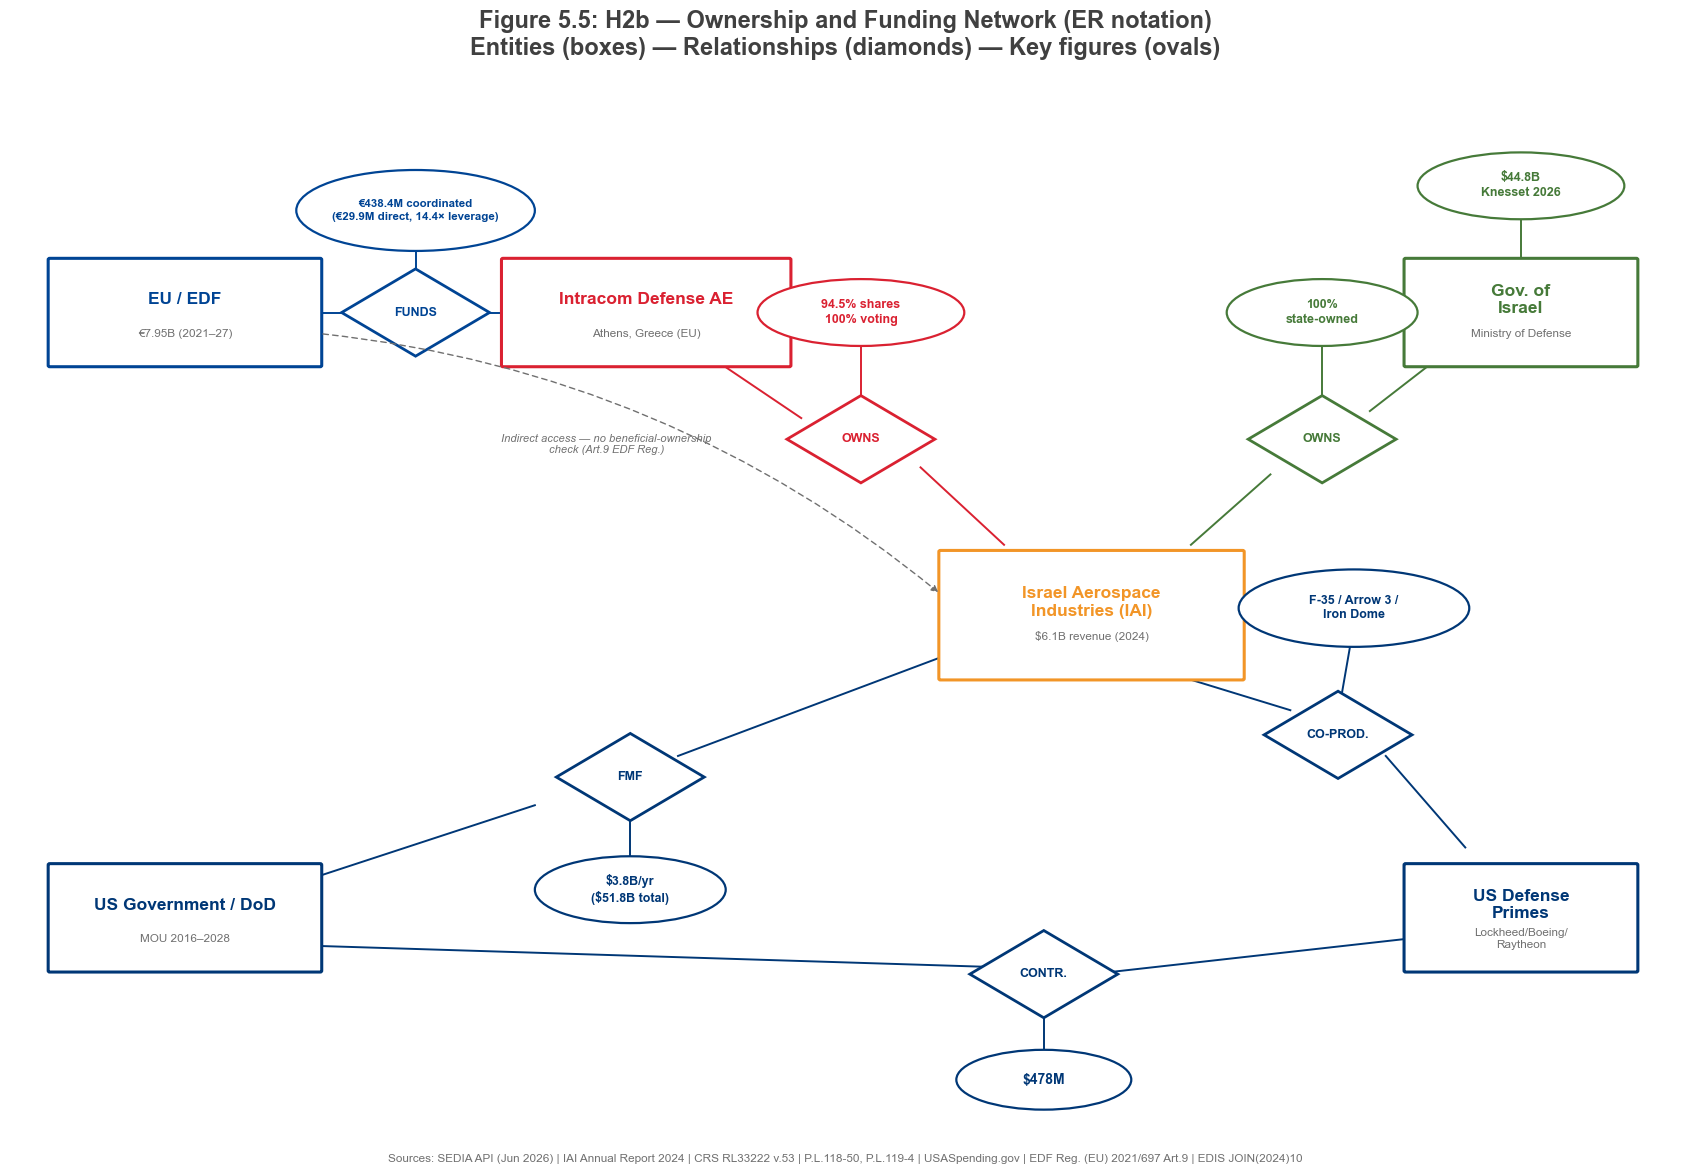

In [ ]:
from matplotlib.patches import Polygon, Ellipse

class EU:
    BLUE='#004494'; BLUE_120='#003776'; ERROR='#DA2131'; WARNING='#F29527'
    SUCCESS='#467A39'; GREY_100='#404040'; GREY_75='#707070'
    WHITE='#FFFFFF'

plt.rcParams.update({'font.family':'Arial', 'figure.facecolor':EU.WHITE})

fig, ax = plt.subplots(figsize=(17, 12))
ax.set_xlim(0, 21)
ax.set_ylim(0, 14)
ax.axis('off')

def entity(ax, cx, cy, w, h, color, label, sub=None):
    ax.add_patch(FancyBboxPatch((cx-w/2, cy-h/2), w, h, boxstyle="round,pad=0.02",
                  facecolor='white', edgecolor=color, lw=2.2, zorder=3))
    ax.text(cx, cy+(0.18 if sub else 0), label, ha='center', va='center',
              fontsize=12.5, fontweight='bold', color=color, zorder=4)
    if sub:
        ax.text(cx, cy-0.3, sub, ha='center', va='center', fontsize=8.5,
                  color=EU.GREY_75, zorder=4)
    return (cx, cy, w, h)

def relationship(ax, cx, cy, s, color, label):
    pts = [(cx, cy+s), (cx+s*1.5, cy), (cx, cy-s), (cx-s*1.5, cy)]
    ax.add_patch(Polygon(pts, closed=True, facecolor='white',
                  edgecolor=color, lw=2.0, zorder=3))
    ax.text(cx, cy, label, ha='center', va='center', fontsize=9,
              fontweight='bold', color=color, zorder=4)
    return (cx, cy)

def attribute(ax, cx, cy, w, h, color, text, fontsize=9.5):
    ax.add_patch(Ellipse((cx, cy), w, h, facecolor='white',
                  edgecolor=color, lw=1.6, zorder=3))
    ax.text(cx, cy, text, ha='center', va='center', fontsize=fontsize,
              fontweight='bold', color=color, zorder=4, linespacing=1.3)
    return (cx, cy)

def link(ax, p1, p2, color, label=None, label_pos=0.5):
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=color, lw=1.4, zorder=2)
    if label:
        mx = p1[0] + (p2[0]-p1[0])*label_pos
        my = p1[1] + (p2[1]-p1[1])*label_pos
        ax.text(mx, my+0.25, label, fontsize=8, color=color, ha='center',
                  va='center', style='italic', zorder=4,
                  bbox=dict(boxstyle='round,pad=0.1', facecolor='white', edgecolor='none', alpha=0.9))


eu        = entity(ax, 2.2, 11.6, 3.4, 1.5, EU.BLUE,      'EU / EDF',            '€7.95B (2021–27)')
usdod     = entity(ax, 2.2, 3.0,  3.4, 1.5, EU.BLUE_120,  'US Government / DoD', 'MOU 2016–2028')
intracom  = entity(ax, 8.0, 11.6, 3.6, 1.5, EU.ERROR,     'Intracom Defense AE', 'Athens, Greece (EU)')
iai       = entity(ax, 13.6, 7.3, 3.8, 1.8, EU.WARNING,   'Israel Aerospace\nIndustries (IAI)', '$6.1B revenue (2024)')
govisr    = entity(ax, 19.0, 11.6, 2.9, 1.5, EU.SUCCESS,   'Gov. of\nIsrael',      'Ministry of Defense')
a7 = attribute(ax, 19.0, 13.4, 2.6, 0.95, EU.SUCCESS, '$44.8B\nKnesset 2026', fontsize=9)
link(ax, (19.0, 12.35), (19.0, 12.93), EU.SUCCESS)
primes    = entity(ax, 19.0, 3.0,  2.9, 1.5, EU.BLUE_120,  'US Defense\nPrimes',   'Lockheed/Boeing/\nRaytheon')

# Relationships (diamonds) + links

# EU -> Intracom : FUNDS
r1 = relationship(ax, 5.1, 11.6, 0.62, EU.BLUE, 'FUNDS')
link(ax, (3.9, 11.6), (4.5, 11.6), EU.BLUE)
link(ax, (5.7, 11.6), (6.2, 11.6), EU.BLUE)
a1 = attribute(ax, 5.1, 13.05, 3.0, 1.15, EU.BLUE,
               '\u20ac438.4M coordinated\n(\u20ac29.9M direct, 14.4\u00d7 leverage)', fontsize=8.3)
link(ax, (5.1, 12.22), (5.1, 12.475), EU.BLUE)

# Intracom -> IAI : OWNS
r2 = relationship(ax, 10.7, 9.8, 0.62, EU.ERROR, 'OWNS')
link(ax, (8.9, 10.9), (9.95, 10.1), EU.ERROR)
link(ax, (11.45, 9.4), (12.5, 8.3), EU.ERROR)
a2 = attribute(ax, 10.7, 11.6, 2.6, 0.95, EU.ERROR, '94.5% shares\n100% voting', fontsize=9)
link(ax, (10.7, 10.42), (10.7, 11.13), EU.ERROR)

# Gov of Israel -> IAI : OWNS
r3 = relationship(ax, 16.5, 9.8, 0.62, EU.SUCCESS, 'OWNS')
link(ax, (17.9, 10.9), (17.1, 10.2), EU.SUCCESS)
link(ax, (15.85, 9.3), (14.85, 8.3), EU.SUCCESS)
a3 = attribute(ax, 16.5, 11.6, 2.4, 0.95, EU.SUCCESS, '100%\nstate-owned', fontsize=9)
link(ax, (16.5, 10.42), (16.5, 11.13), EU.SUCCESS)

# US Gov -> IAI : PROVIDES FMF
r4 = relationship(ax, 7.8, 5.0, 0.62, EU.BLUE_120, 'FMF')
link(ax, (3.9, 3.6), (6.6, 4.6), EU.BLUE_120)
link(ax, (8.4, 5.3), (11.7, 6.7), EU.BLUE_120)
a4 = attribute(ax, 7.8, 3.4, 2.4, 0.95, EU.BLUE_120, '$3.8B/yr\n($51.8B total)', fontsize=9)
link(ax, (7.8, 4.4), (7.8, 3.87), EU.BLUE_120)

# US Gov -> US Defense Primes : CONTRACTS
r5 = relationship(ax, 13.0, 2.2, 0.62, EU.BLUE_120, 'CONTR.')
link(ax, (3.9, 2.6), (12.4, 2.3), EU.BLUE_120)
link(ax, (13.6, 2.2), (17.55, 2.7), EU.BLUE_120)
a5 = attribute(ax, 13.0, 0.7, 2.2, 0.85, EU.BLUE_120, '$478M', fontsize=10)
link(ax, (13.0, 1.6), (13.0, 1.12), EU.BLUE_120)

# IAI -> US Defense Primes : CO-PRODUCES
r6 = relationship(ax, 16.7, 5.6, 0.62, EU.BLUE_120, 'CO-PROD.')
link(ax, (14.8, 6.4), (16.1, 5.95), EU.BLUE_120)
link(ax, (17.3, 5.3), (18.3, 4.0), EU.BLUE_120)
a6 = attribute(ax, 16.9, 7.4, 2.9, 1.1, EU.BLUE_120, 'F-35 / Arrow 3 /\nIron Dome', fontsize=9)
link(ax, (16.75, 6.2), (16.85, 6.85), EU.BLUE_120)

# Indirect access note (EU -> IAI, dashed, no beneficial ownership check)
ax.annotate('', xy=(11.7, 7.6), xytext=(3.9, 11.3),
            arrowprops=dict(arrowstyle='-|>', color=EU.GREY_75, lw=1.0,
                            linestyle=(0, (4, 3)), connectionstyle='arc3,rad=-0.15'))
ax.text(7.5, 9.6, 'Indirect access — no beneficial-ownership\ncheck (Art.9 EDF Reg.)',
          fontsize=8, color=EU.GREY_75, ha='center', style='italic')

fig.suptitle('Figure 5.5: H2b — Ownership and Funding Network (ER notation)\n'
             'Entities (boxes) \u2014 Relationships (diamonds) \u2014 Key figures (ovals)',
             fontsize=17, fontweight='bold', color=EU.GREY_100, y=0.985)

fig.text(0.5, 0.025,
    'Sources: SEDIA API (Jun 2026) | IAI Annual Report 2024 | CRS RL33222 v.53 | P.L.118-50, P.L.119-4 | '
    'USASpending.gov | EDF Reg. (EU) 2021/697 Art.9 | EDIS JOIN(2024)10',
    ha='center', fontsize=8.5, color=EU.GREY_75)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])
SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)
out = SAVE_PATH + 'figure_5_5ac_ER_style_corrected.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()

In [ ]:
pd.set_option('display.max_colwidth', 200)

for var in ['df']:
    if var not in dir():
        raise NameError("'df' not found — load your main dataframe first.")

df['metadata_title'] = df['metadata_title'].fillna('').astype(str)

PROXY = ['INTRACOM DEFENSE', 'OPTRONIC INSTRUMENTS', 'OIP SENSOR']
edf = df[df['programme'] == 'EDF'].copy()
edf['is_proxy'] = edf['metadata_legalEntityNames'].astype(str).str.upper().apply(
    lambda x: any(p in x for p in PROXY))
edf_proxy = edf[edf['is_proxy']].copy()

print("="*90)
print(f"Found {len(edf_proxy)} EDF projects with Intracom/OIP listed in legalEntityNames")
print("="*90)

def parse_participants(raw):
    if pd.isna(raw):
        return []
    if isinstance(raw, list):
        return raw
    try:
        return ast.literal_eval(raw)
    except Exception:
        return []

total_intracom_eur = 0
total_oip_eur = 0
rows_out = []

for idx, row in edf_proxy.iterrows():
    title = row['metadata_title']
    participants = parse_participants(row.get('metadata_participants'))
    if not participants:
        print(f"\n[{title[:60]}] -> metadata_participants not parseable, raw type: {type(row.get('metadata_participants'))}")
        continue
    for p in participants:
        name = str(p.get('legalName', ''))
        if 'INTRACOM' in name.upper():
            contrib = p.get('eucontribution', 'N/A')
            role = p.get('role', 'N/A')
            country = p.get('address_country_description', 'N/A')
            print(f"\n[{title[:55]}]")
            print(f"  Entity: {name} | Role: {role} | Country: {country} | EU contribution: {contrib}")
            rows_out.append((title, name, role, contrib))
            try:
                total_intracom_eur += float(contrib)
            except (ValueError, TypeError):
                pass
        if 'OIP' in name.upper() or 'OPTRONIC' in name.upper():
            contrib = p.get('eucontribution', 'N/A')
            role = p.get('role', 'N/A')
            country = p.get('address_country_description', 'N/A')
            print(f"\n[{title[:55]}]")
            print(f"  Entity: {name} | Role: {role} | Country: {country} | EU contribution: {contrib}")
            rows_out.append((title, name, role, contrib))
            try:
                total_oip_eur += float(contrib)
            except (ValueError, TypeError):
                pass

print("\n" + "="*90)
print("SUMMARY")
print("="*90)
print(f"Total Intracom Defense AE EU contribution across all projects: EUR {total_intracom_eur:,.0f}")
print(f"Total OIP/Optronic EU contribution across all projects: EUR {total_oip_eur:,.0f}")
print(f"Combined: EUR {total_intracom_eur + total_oip_eur:,.0f}")
print("\nCompare to project-level total previously cited: EUR 438.4M")
print("If participant-level sum is non-zero and roughly matches, the funding claim is CONFIRMED.")
print("If it's zero or far off, we have the same problem as the Ukraine case and must investigate.")

Found 18 EDF projects with Intracom/OIP listed in legalEntityNames

[ArmoURed Infantry Ground Assault]
  Entity: HENSOLDT OPTRONICS GMBH | Role: participant | Country: Germany | EU contribution: 482763.03

[ArmoURed Infantry Ground Assault]
  Entity: INTRACOM DEFENSE AE | Role: participant | Country: Greece | EU contribution: 394633.43

[Sustainable Energy Capabilities for Enhanced Military C]
  Entity: INTRACOM DEFENSE AE | Role: participant | Country: Greece | EU contribution: 1496164.05

[5G Communications for Peacekeeping and Defence 2.0]
  Entity: INTRACOM DEFENSE AE | Role: participant | Country: Greece | EU contribution: 120665

[Advanced capabilities & Certification for Tactical UAV ]
  Entity: INTRACOM DEFENSE AE | Role: coordinator | Country: Greece | EU contribution: 14294655.35

[Autonomous SSA Bodyguard Onboard Satellite]
  Entity: OPTRONIC INSTRUMENTS & PRODUCTS | Role: participant | Country: Belgium | EU contribution: 565875

[Generative Automation of Security Penetratio

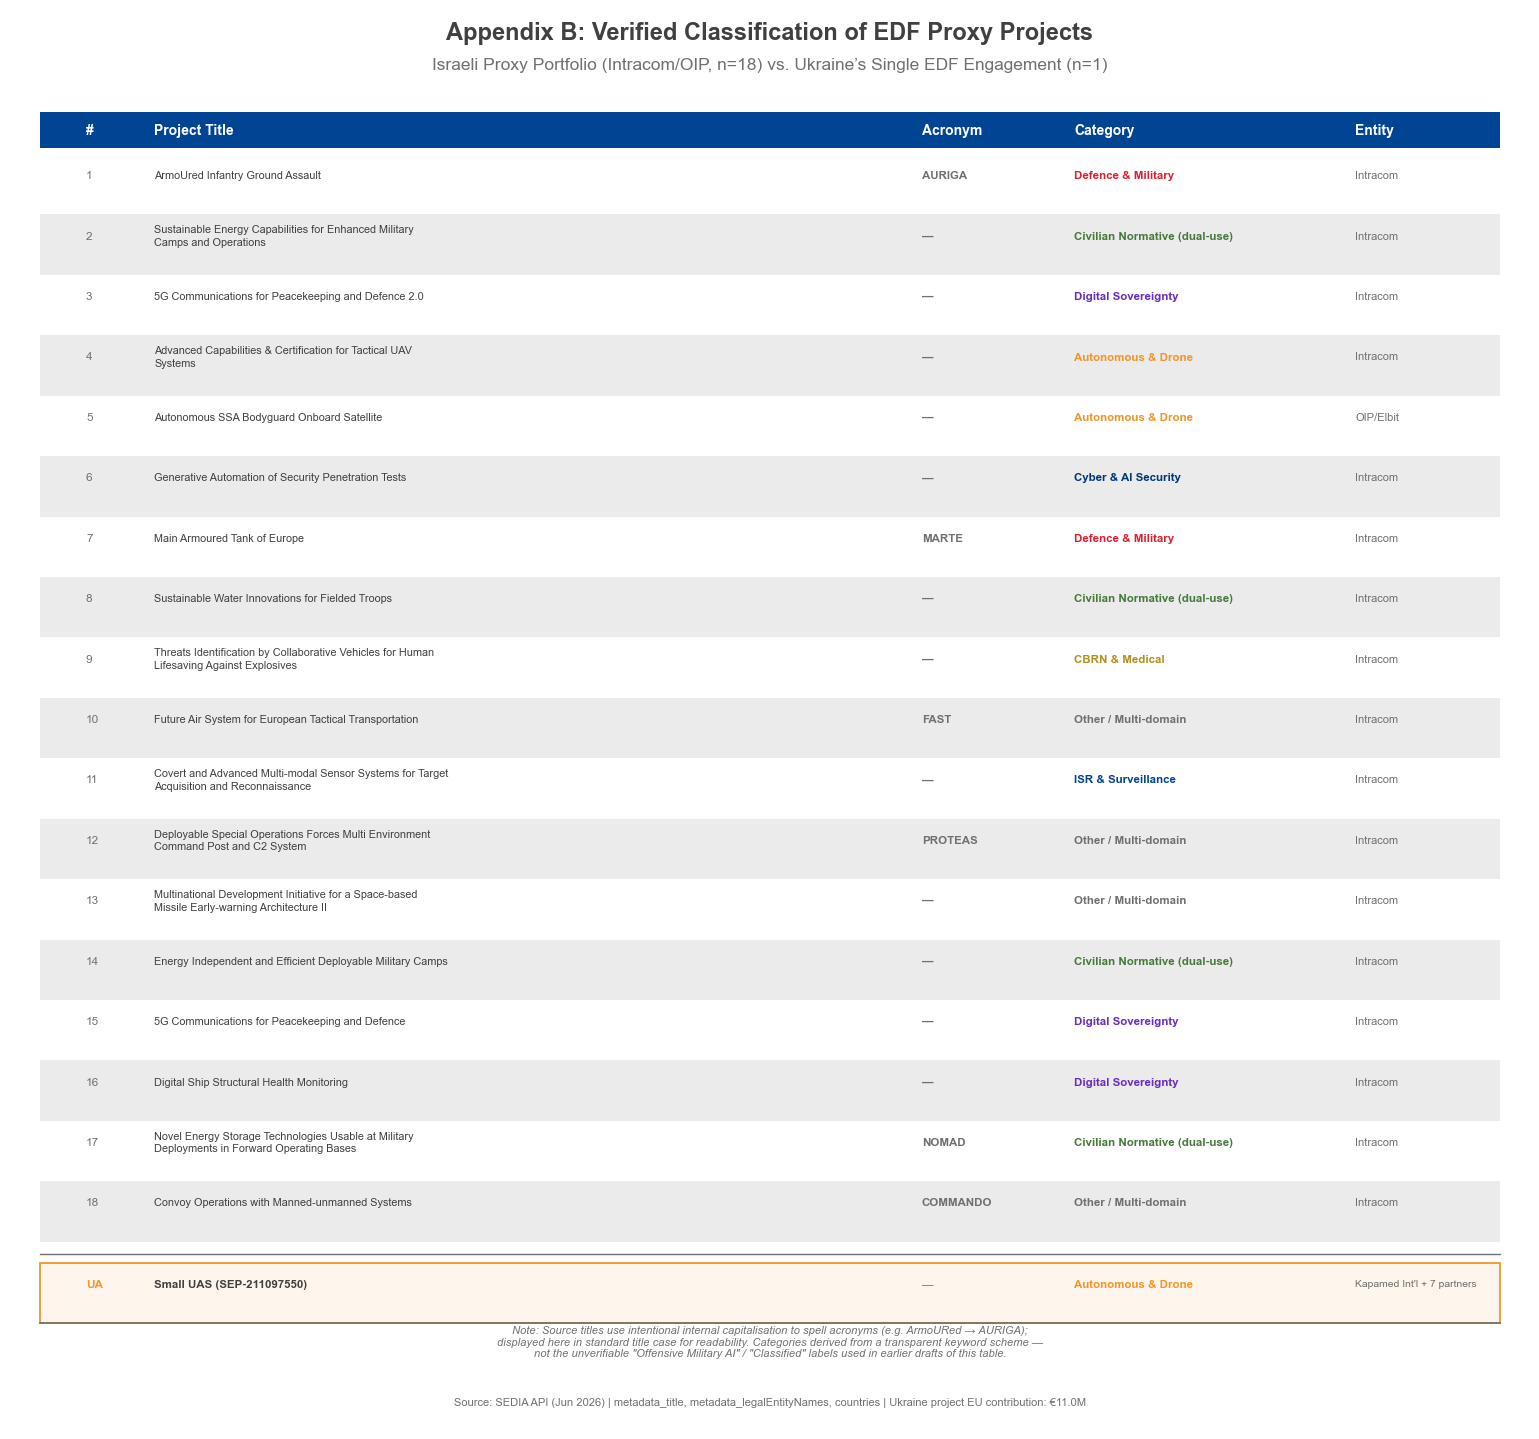

In [ ]:

class EU:
    BLUE='#004494'; ERROR='#DA2131'; WARNING='#F29527'; SUCCESS='#467A39'
    GREY_100='#404040'; GREY_75='#707070'; GREY_10='#EBEBEB'; WHITE='#FFFFFF'

plt.rcParams.update({'font.family':'Arial', 'figure.facecolor':EU.WHITE})

rows = [
    ("ArmoUred Infantry Ground Assault", "AURIGA", "Defence & Military", "Intracom"),
    ("Sustainable Energy Capabilities for Enhanced Military Camps and Operations", "\u2014", "Civilian Normative (dual-use)", "Intracom"),
    ("5G Communications for Peacekeeping and Defence 2.0", "\u2014", "Digital Sovereignty", "Intracom"),
    ("Advanced Capabilities & Certification for Tactical UAV Systems", "\u2014", "Autonomous & Drone", "Intracom"),
    ("Autonomous SSA Bodyguard Onboard Satellite", "\u2014", "Autonomous & Drone", "OIP/Elbit"),
    ("Generative Automation of Security Penetration Tests", "\u2014", "Cyber & AI Security", "Intracom"),
    ("Main Armoured Tank of Europe", "MARTE", "Defence & Military", "Intracom"),
    ("Sustainable Water Innovations for Fielded Troops", "\u2014", "Civilian Normative (dual-use)", "Intracom"),
    ("Threats Identification by Collaborative Vehicles for Human Lifesaving Against Explosives", "\u2014", "CBRN & Medical", "Intracom"),
    ("Future Air System for European Tactical Transportation", "FAST", "Other / Multi-domain", "Intracom"),
    ("Covert and Advanced Multi-modal Sensor Systems for Target Acquisition and Reconnaissance", "\u2014", "ISR & Surveillance", "Intracom"),
    ("Deployable Special Operations Forces Multi Environment Command Post and C2 System", "PROTEAS", "Other / Multi-domain", "Intracom"),
    ("Multinational Development Initiative for a Space-based Missile Early-warning Architecture II", "\u2014", "Other / Multi-domain", "Intracom"),
    ("Energy Independent and Efficient Deployable Military Camps", "\u2014", "Civilian Normative (dual-use)", "Intracom"),
    ("5G Communications for Peacekeeping and Defence", "\u2014", "Digital Sovereignty", "Intracom"),
    ("Digital Ship Structural Health Monitoring", "\u2014", "Digital Sovereignty", "Intracom"),
    ("Novel Energy Storage Technologies Usable at Military Deployments in Forward Operating Bases", "NOMAD", "Civilian Normative (dual-use)", "Intracom"),
    ("Convoy Operations with Manned-unmanned Systems", "COMMANDO", "Other / Multi-domain", "Intracom"),
]

ukraine_row = ("Small UAS (SEP-211097550)", "\u2014", "Autonomous & Drone", "Kapamed Int'l + 7 partners")

cat_colors = {
    'Defence & Military': EU.ERROR,
    'Autonomous & Drone': EU.WARNING,
    'ISR & Surveillance': EU.BLUE,
    'Cyber & AI Security': '#003776',
    'Digital Sovereignty': '#672DC4',
    'Civilian Normative (dual-use)': EU.SUCCESS,
    'CBRN & Medical': '#B09120',
    'Other / Multi-domain': EU.GREY_75,
}

n = len(rows)
fig, ax = plt.subplots(figsize=(15.5, 14.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, n + 5.5)
ax.axis('off')

ax.text(5, n+5.0, 'Appendix B: Verified Classification of EDF Proxy Projects',
          ha='center', fontsize=17, fontweight='bold', color=EU.GREY_100)
ax.text(5, n+4.5, 'Israeli Proxy Portfolio (Intracom/OIP, n=18) vs. Ukraine\u2019s Single EDF Engagement (n=1)',
          ha='center', fontsize=12.5, color=EU.GREY_75)

header_y = n + 3.7
ax.add_patch(FancyBboxPatch((0.2, header_y-0.5), 9.6, 0.6, boxstyle="square,pad=0",
              facecolor=EU.BLUE, edgecolor='none'))
ax.text(0.5, header_y-0.2, '#', fontsize=10, fontweight='bold', color='white', va='center')
ax.text(0.95, header_y-0.2, 'Project Title', fontsize=10, fontweight='bold', color='white', va='center')
ax.text(6.0, header_y-0.2, 'Acronym', fontsize=10, fontweight='bold', color='white', va='center')
ax.text(7.0, header_y-0.2, 'Category', fontsize=10, fontweight='bold', color='white', va='center')
ax.text(8.85, header_y-0.2, 'Entity', fontsize=10, fontweight='bold', color='white', va='center')

row_h = 1.0
y_start = header_y - 0.6
for i, (title, acro, cat, entity) in enumerate(rows, 1):
    y = y_start - (i-1)*row_h
    bg = EU.GREY_10 if i % 2 == 0 else EU.WHITE
    ax.add_patch(FancyBboxPatch((0.2, y-row_h), 9.6, row_h, boxstyle="square,pad=0",
                  facecolor=bg, edgecolor='none'))
    color = cat_colors[cat]
    ax.text(0.5, y-row_h/2+0.15, str(i), fontsize=8.5, color=EU.GREY_75, va='center')
    # wrap long titles
    import textwrap
    wrapped = textwrap.fill(title, width=58)
    ax.text(0.95, y-row_h/2+0.15, wrapped, fontsize=7.8, color=EU.GREY_100, va='center', linespacing=1.3)
    ax.text(6.0, y-row_h/2+0.15, acro, fontsize=8.3, fontweight='bold', color=EU.GREY_75, va='center')
    ax.text(7.0, y-row_h/2+0.15, cat, fontsize=8.3, fontweight='bold', color=color, va='center')
    ax.text(8.85, y-row_h/2+0.15, entity, fontsize=8, color=EU.GREY_75, va='center')

ukr_y = y_start - n*row_h - 0.35
ax.plot([0.2, 9.8], [ukr_y+0.15, ukr_y+0.15], color=EU.GREY_75, lw=1.0)
ax.add_patch(FancyBboxPatch((0.2, ukr_y-row_h), 9.6, row_h, boxstyle="square,pad=0",
              facecolor='#FEF6EC', edgecolor=EU.WARNING, lw=1.3))
title, acro, cat, entity = ukraine_row
ax.text(0.5, ukr_y-row_h/2+0.15, 'UA', fontsize=8.5, fontweight='bold', color=EU.WARNING, va='center')
ax.text(0.95, ukr_y-row_h/2+0.15, title, fontsize=8.3, fontweight='bold', color=EU.GREY_100, va='center')
ax.text(6.0, ukr_y-row_h/2+0.15, acro, fontsize=8.3, color=EU.GREY_75, va='center')
ax.text(7.0, ukr_y-row_h/2+0.15, cat, fontsize=8.3, fontweight='bold', color=cat_colors[cat], va='center')
ax.text(8.85, ukr_y-row_h/2+0.15, entity, fontsize=7.5, color=EU.GREY_75, va='center')

table_bottom = ukr_y - row_h
ax.plot([0.2, 9.8], [table_bottom, table_bottom], color=EU.GREY_75, lw=1.2)

ax.text(5, table_bottom-0.55,
    'Note: Source titles use intentional internal capitalisation to spell acronyms (e.g. ArmoURed \u2192 AURIGA);\n'
    'displayed here in standard title case for readability. Categories derived from a transparent keyword scheme \u2014\n'
    'not the unverifiable "Offensive Military AI" / "Classified" labels used in earlier drafts of this table.',
    ha='center', fontsize=8, color=EU.GREY_75, style='italic')

ax.text(5, table_bottom-1.35,
    'Source: SEDIA API (Jun 2026) | metadata_title, metadata_legalEntityNames, countries | '
    'Ukraine project EU contribution: \u20ac11.0M',
    ha='center', fontsize=8, color=EU.GREY_75)

plt.tight_layout()
SAVE_PATH = '/Users/elif/Desktop/Utrecht-thesis/figures/'
os.makedirs(SAVE_PATH, exist_ok=True)
out = SAVE_PATH + 'Appendix_B_corrected.png'
fig.savefig(out, dpi=300, bbox_inches='tight', facecolor=EU.WHITE)
plt.show()